# EDA Lengkap: Text-to-SQL Pipeline
**Skripsi:** Analisis Trade-off Performa dan Efisiensi Token pada Sistem Text-to-SQL  
**Metrik:** Exact-Set-Match (ESM) & Token Elasticity of Performance (TEP)  
**Perbandingan:** Baseline RAG vs Graph-based RAG

---
**Isi Notebook:**
1. Konfigurasi & Load Data
2. Overview Dataset
3. Kompleksitas Skema Database
4. Kompleksitas SQL (Hardness, Clause, Length)
5. Analisis Pertanyaan Natural Language
6. **Analisis Token** — fondasi TEP (inti skripsi)
7. Token Budget: Baseline RAG vs GraphRAG
8. Schema Linking Analysis
9. Few-shot Examples Analysis
10. Ringkasan EDA

In [1]:
import json, re, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Plotting style ──────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': 'white',
                     'axes.facecolor': 'white', 'grid.alpha': 0.35})
PAL = sns.color_palette('muted', 10)

# ── Token counter ────────────────────────────────────────────────────────
# Menggunakan tiktoken cl100k_base sebagai proxy untuk Qwen tokenizer.
# Jika tidak tersedia, fallback ke whitespace split.
try:
    import tiktoken
    _enc = tiktoken.get_encoding('cl100k_base')
    count_tokens = lambda t: len(_enc.encode(str(t)))
    TOKEN_METHOD = 'tiktoken cl100k_base (proxy Qwen)'
except ImportError:
    count_tokens = lambda t: len(str(t).split())
    TOKEN_METHOD = 'whitespace split  <-- install tiktoken untuk lebih akurat'

print(f'Token method : {TOKEN_METHOD}')
print('Import selesai ✓')

Token method : tiktoken cl100k_base (proxy Qwen)
Import selesai ✓


## 1. Konfigurasi Path Dataset
Sesuaikan `BASE_PATH` dengan lokasi dataset yang digunakan.  
Notebook ini mendukung **IDSpider** (dataset ini) maupun **English Spider**.

In [4]:
# ── Sesuaikan path di bawah ini ─────────────────────────────────────────
BASE_PATH = Path('/kaggle/input/datasets/alrette/spiderdataset/spider_data')  # English Spider

TABLES_JSON = BASE_PATH / 'tables.json'
TRAIN_JSON  = BASE_PATH / 'train_spider.json'
DEV_JSON    = BASE_PATH / 'dev.json'

# ── Pipeline hyperparameter (dari PipelineConfig) ────────────────────────
FEW_SHOT_K     = 3
TOP_K_TABLES   = 3
TOP_K_COLUMNS  = 5
SIM_THRESHOLD  = 0.35
SYSTEM_TOKENS  = 80   # estimasi token system prompt (tetap)

# ── Validasi keberadaan file ─────────────────────────────────────────────
print('Validasi file dataset:')
for p in [TABLES_JSON, TRAIN_JSON, DEV_JSON]:
    icon = '✓' if p.exists() else '✗  <-- FILE TIDAK DITEMUKAN'
    print(f'  {icon}  {p.name}')

Validasi file dataset:
  ✓  tables.json
  ✓  train_spider.json
  ✓  dev.json


## 2. Load & Validasi Data

In [5]:
def load_schema_cols(path):
    # tables.json -> DataFrame per kolom (row = satu kolom di satu tabel)
    with open(path, encoding='utf-8') as f:
        dbs = json.load(f)
    rows = []
    for db in dbs:
        db_id  = db['db_id']
        tbls   = db.get('table_names_original', db['table_names'])
        cols   = db.get('column_names_original', db['column_names'])
        ctypes = db['column_types']
        pks    = set(db['primary_keys'])
        fk_map = {a: b for a, b in db['foreign_keys']}
        for i, (ti, cname) in enumerate(cols):
            if ti == -1:
                continue  # skip wildcard *
            fk_rel = '-'
            if i in fk_map:
                tt, tc = cols[fk_map[i]]
                fk_rel = f'{tbls[tt]}.{tc}'
            rows.append({'db_id': db_id, 'table': tbls[ti], 'column': cname,
                          'type': ctypes[i], 'is_pk': i in pks,
                          'is_fk': i in fk_map, 'fk_target': fk_rel})
    return pd.DataFrame(rows)


def load_schema_db(path):
    # tables.json -> DataFrame per database (aggregated metrics)
    with open(path, encoding='utf-8') as f:
        dbs = json.load(f)
    rows = []
    for db in dbs:
        tbls = db.get('table_names_original', db['table_names'])
        cols = db.get('column_names_original', db['column_names'])
        real = [(t, c) for t, c in cols if t != -1]
        rows.append({'db_id': db['db_id'],
                      'n_tables':  len(tbls),
                      'n_columns': len(real),
                      'n_pk':      len(db['primary_keys']),
                      'n_fk':      len(db['foreign_keys'])})
    return pd.DataFrame(rows)


def load_queries(path):
    # train/dev.json -> DataFrame
    with open(path, encoding='utf-8') as f:
        data = json.load(f)
    return pd.DataFrame(data)


print('Fungsi loader siap ✓')

Fungsi loader siap ✓


In [6]:
col_df   = load_schema_cols(TABLES_JSON)
db_df    = load_schema_db(TABLES_JSON)
df_train = load_queries(TRAIN_JSON)
df_dev   = load_queries(DEV_JSON)

# Deteksi nama kolom SQL & question secara otomatis
SQL_COL = 'query' if 'query' in df_train.columns else ('sql_query' if 'sql_query' in df_train.columns else 'sql')
Q_COL   = 'question'

print(f'Schema  — database  : {len(db_df):>5,}')
print(f'Schema  — kolom     : {len(col_df):>5,}')
print(f'Train queries       : {len(df_train):>5,}')
print(f'Dev   queries       : {len(df_dev):>5,}')
print(f'\nSQL column  : {SQL_COL!r}')
print(f'Kolom train : {list(df_train.columns)}')
print(f'Kolom dev   : {list(df_dev.columns)}')

Schema  — database  :   166
Schema  — kolom     : 4,503
Train queries       : 7,000
Dev   queries       : 1,034

SQL column  : 'query'
Kolom train : ['db_id', 'query', 'query_toks', 'query_toks_no_value', 'question', 'question_toks', 'sql']
Kolom dev   : ['db_id', 'query', 'query_toks', 'query_toks_no_value', 'question', 'question_toks', 'sql']


## 3. Overview Dataset

   RINGKASAN DATASET
  Total database               :    166
  DB di train                  :    140
  DB di dev                    :     20
  DB overlap (train∩dev)       :      0
  Train queries                :  7,000
  Dev queries                  :  1,034
  Total queries                :  8,034
  Total tabel (unik)           :    876
  Total kolom                  :  4,503
  Total PK                     :    781
  Total FK                     :    795


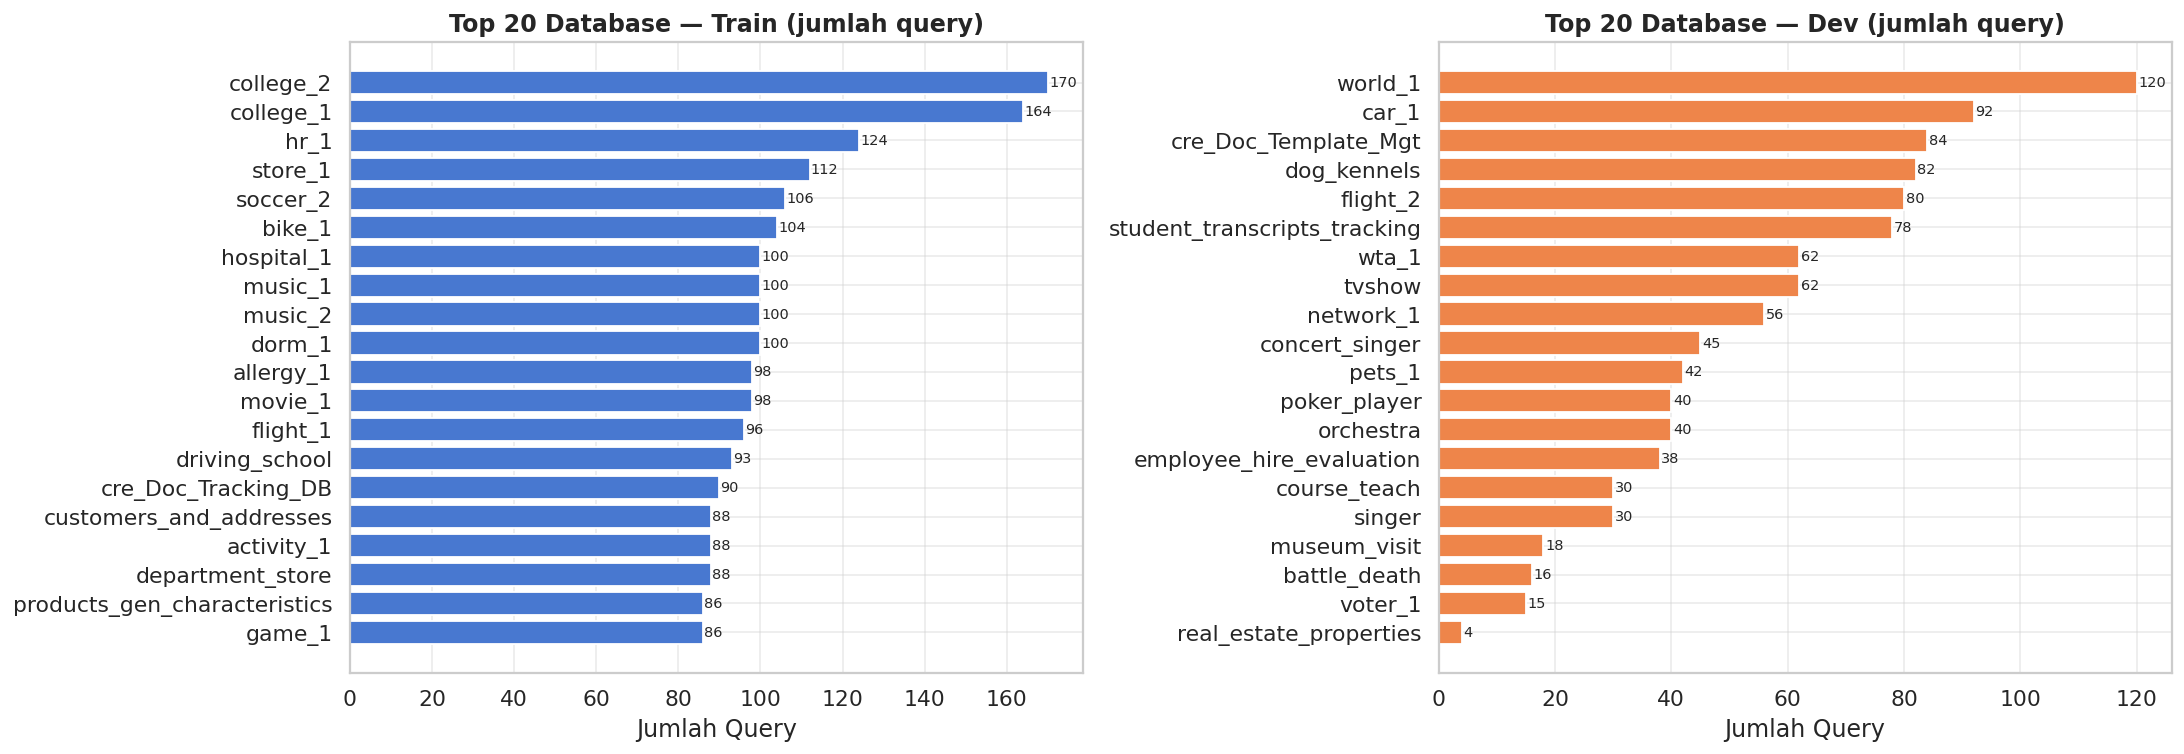

In [7]:
train_dbs = set(df_train['db_id'].unique())
dev_dbs   = set(df_dev['db_id'].unique())

summary = {
    'Total database'         : db_df['db_id'].nunique(),
    'DB di train'            : len(train_dbs),
    'DB di dev'              : len(dev_dbs),
    'DB overlap (train∩dev)' : len(train_dbs & dev_dbs),
    'Train queries'          : len(df_train),
    'Dev queries'            : len(df_dev),
    'Total queries'          : len(df_train) + len(df_dev),
    'Total tabel (unik)'     : col_df[['db_id','table']].drop_duplicates().__len__(),
    'Total kolom'            : len(col_df),
    'Total PK'               : db_df['n_pk'].sum(),
    'Total FK'               : db_df['n_fk'].sum(),
}

print('=' * 44)
print('   RINGKASAN DATASET')
print('=' * 44)
for k, v in summary.items():
    print(f'  {k:<28} : {v:>6,}')
print('=' * 44)

# ── Bar chart: top 20 DB per jumlah query ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

for ax, (df, label, color) in zip(axes, [
        (df_train, 'Train', PAL[0]),
        (df_dev,   'Dev',   PAL[1])]):
    counts = df['db_id'].value_counts().head(20)
    ax.barh(counts.index[::-1], counts.values[::-1], color=color, edgecolor='white')
    ax.set_title(f'Top 20 Database — {label} (jumlah query)', fontweight='bold')
    ax.set_xlabel('Jumlah Query')
    for i, v in enumerate(counts.values[::-1]):
        ax.text(v + 0.3, i, str(v), va='center', fontsize=8)

plt.tight_layout()
plt.savefig('plot_01_queries_per_db.png', bbox_inches='tight')
plt.show()

## 4. Analisis Kompleksitas Skema Database
Kompleksitas skema menentukan jumlah **node & edge** di graph (GraphRAG) dan banyaknya **token skema**  
yang diinjeksikan ke prompt — variabel kunci untuk menganalisis trade-off token.

In [8]:
cols_per_table = col_df.groupby(['db_id','table']).size().reset_index(name='n_cols')

print('Statistik Deskriptif Skema per Database:')
print(db_df[['n_tables','n_columns','n_pk','n_fk']].describe().round(2))

print('\nTop 10 database paling kompleks (by jumlah tabel):')
top10 = db_df.nlargest(10, 'n_tables')[['db_id','n_tables','n_columns','n_pk','n_fk']]
print(top10.to_string(index=False))

print('\nDistribusi tipe kolom:')
print(col_df['type'].value_counts().to_string())

Statistik Deskriptif Skema per Database:
       n_tables  n_columns    n_pk    n_fk
count    166.00     166.00  166.00  166.00
mean       5.28      27.13    4.70    4.79
std        3.87      30.80    3.38    4.81
min        2.00       6.00    0.00    0.00
25%        3.00      13.00    3.00    2.00
50%        4.00      19.50    3.00    3.00
75%        7.00      30.75    5.75    6.00
max       26.00     352.00   18.00   25.00

Top 10 database paling kompleks (by jumlah tabel):
                    db_id  n_tables  n_columns  n_pk  n_fk
               baseball_1        26        352     0    19
cre_Drama_Workshop_Groups        18         99    18    25
                     imdb        16         66    15    11
                 sakila_1        16         89    16    21
           cre_Theme_park        16         52    16    14
                 academic        15         42    14    18
               hospital_1        15         68    15    25
         department_store        14         56  

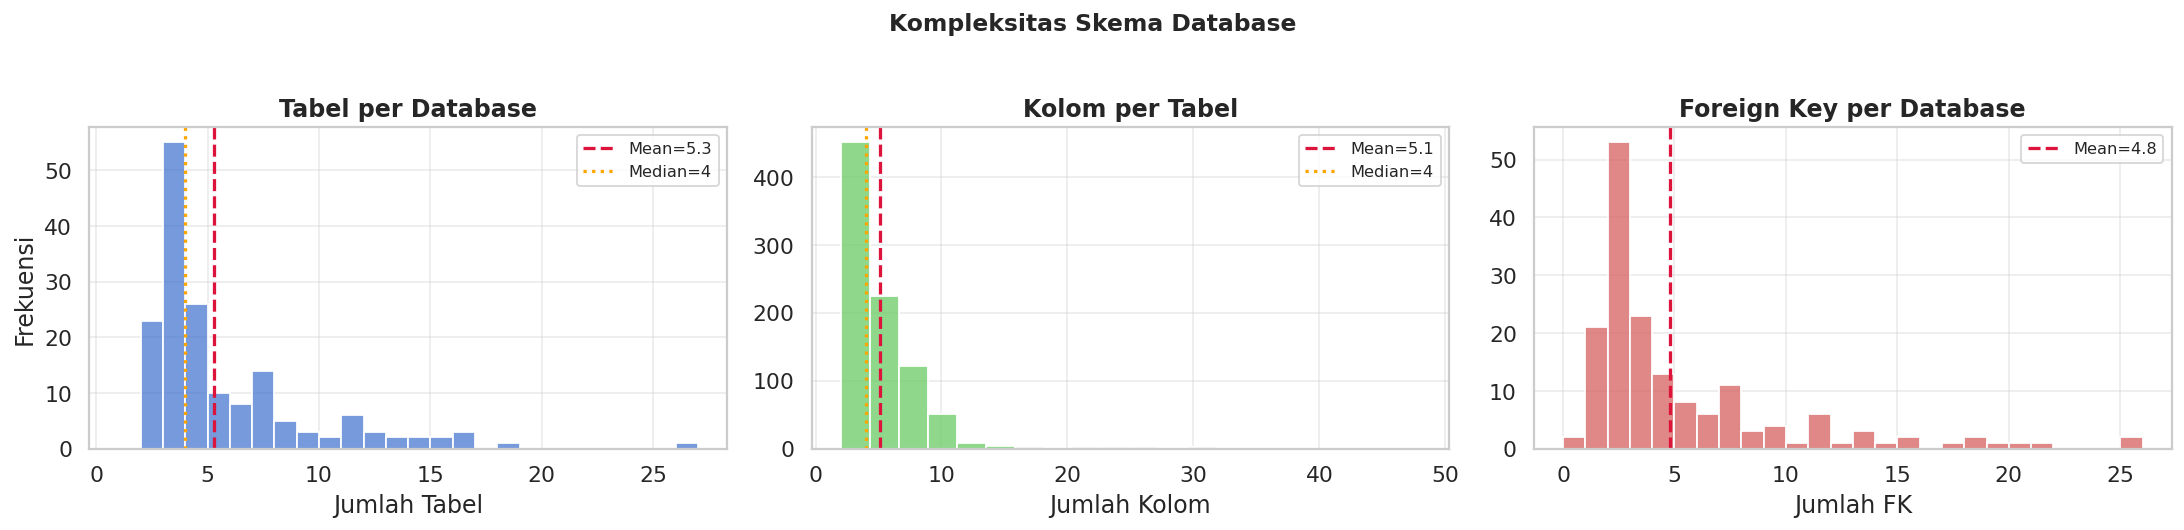

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# Panel 1: Tables per DB
ax = axes[0]
bins_t = range(1, db_df['n_tables'].max() + 2)
sns.histplot(db_df['n_tables'], bins=bins_t, ax=ax, color=PAL[0], edgecolor='white')
ax.axvline(db_df['n_tables'].mean(),   color='crimson', lw=1.8, ls='--',
           label=f"Mean={db_df['n_tables'].mean():.1f}")
ax.axvline(db_df['n_tables'].median(), color='orange',  lw=1.8, ls=':',
           label=f"Median={db_df['n_tables'].median():.0f}")
ax.set_title('Tabel per Database', fontweight='bold')
ax.set_xlabel('Jumlah Tabel'); ax.set_ylabel('Frekuensi'); ax.legend(fontsize=9)

# Panel 2: Columns per Table
ax = axes[1]
sns.histplot(cols_per_table['n_cols'], bins=20, ax=ax, color=PAL[2], edgecolor='white')
ax.axvline(cols_per_table['n_cols'].mean(),   color='crimson', lw=1.8, ls='--',
           label=f"Mean={cols_per_table['n_cols'].mean():.1f}")
ax.axvline(cols_per_table['n_cols'].median(), color='orange',  lw=1.8, ls=':',
           label=f"Median={cols_per_table['n_cols'].median():.0f}")
ax.set_title('Kolom per Tabel', fontweight='bold')
ax.set_xlabel('Jumlah Kolom'); ax.set_ylabel(''); ax.legend(fontsize=9)

# Panel 3: FK per DB
ax = axes[2]
bins_fk = range(0, db_df['n_fk'].max() + 2)
sns.histplot(db_df['n_fk'], bins=bins_fk, ax=ax, color=PAL[3], edgecolor='white')
ax.axvline(db_df['n_fk'].mean(), color='crimson', lw=1.8, ls='--',
           label=f"Mean={db_df['n_fk'].mean():.1f}")
ax.set_title('Foreign Key per Database', fontweight='bold')
ax.set_xlabel('Jumlah FK'); ax.set_ylabel(''); ax.legend(fontsize=9)

plt.suptitle('Kompleksitas Skema Database', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_02_schema_complexity.png', bbox_inches='tight')
plt.show()

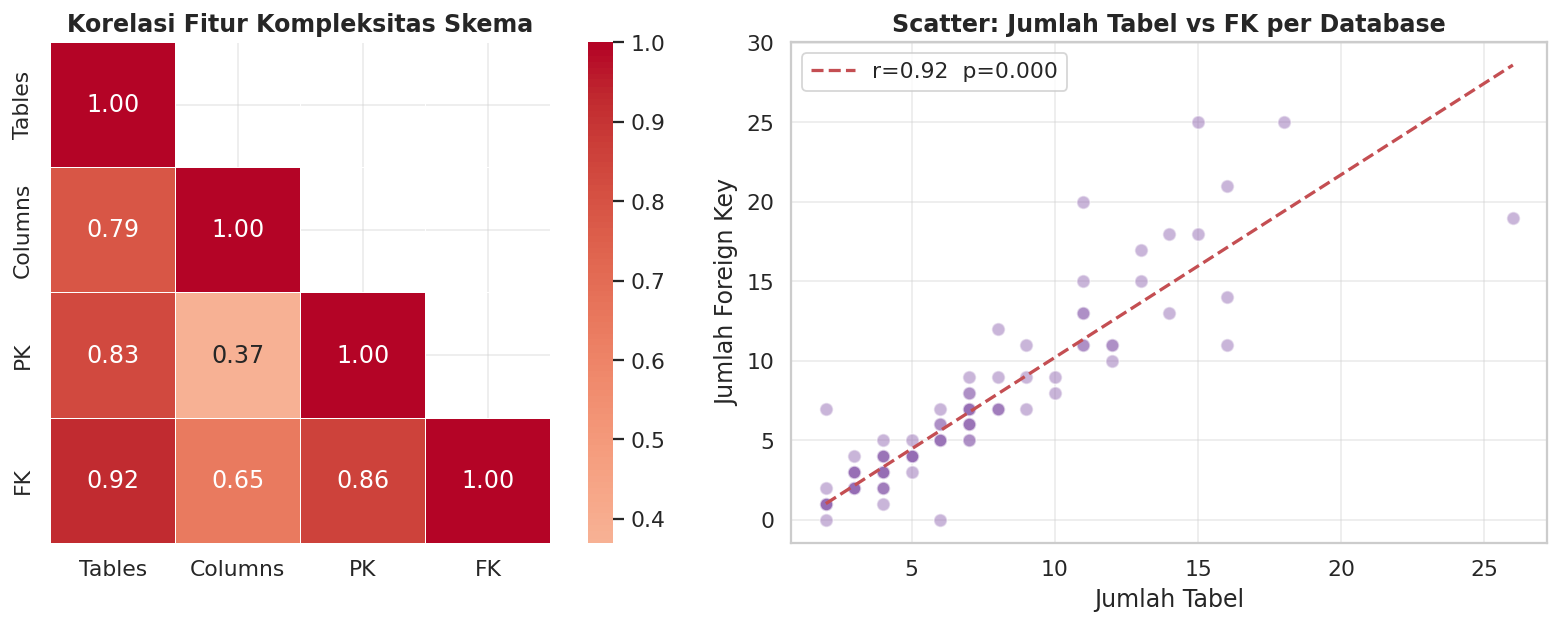

Interpretasi: setiap tambahan 1 tabel berkorelasi dengan +1.15 FK (r=0.92)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Heatmap korelasi
ax = axes[0]
corr = db_df[['n_tables','n_columns','n_pk','n_fk']].corr()
corr.index   = ['Tables','Columns','PK','FK']
corr.columns = ['Tables','Columns','PK','FK']
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, square=True, mask=mask)
ax.set_title('Korelasi Fitur Kompleksitas Skema', fontweight='bold')

# Scatter: Tables vs FK
ax = axes[1]
ax.scatter(db_df['n_tables'], db_df['n_fk'], alpha=0.5,
           color=PAL[4], edgecolors='white', s=55)
m, b, r, p, _ = stats.linregress(db_df['n_tables'], db_df['n_fk'])
xr = np.linspace(db_df['n_tables'].min(), db_df['n_tables'].max(), 100)
ax.plot(xr, m * xr + b, 'r--', lw=1.8,
        label=f'r={r:.2f}  p={p:.3f}')
ax.set_xlabel('Jumlah Tabel'); ax.set_ylabel('Jumlah Foreign Key')
ax.set_title('Scatter: Jumlah Tabel vs FK per Database', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('plot_03_schema_corr.png', bbox_inches='tight')
plt.show()

print(f'Interpretasi: setiap tambahan 1 tabel berkorelasi dengan +{m:.2f} FK (r={r:.2f})')

### Validasi Statistik Schema Graph (§3.4.1)
Memverifikasi jumlah node dan edge yang akan dihasilkan proses konstruksi schema-to-graph.  
Skripsi §3.4.1 menyebutkan **4.486 node** dan **3.846 edge**.

In [12]:
# ── Reproduksi statistik Schema Graph dari §3.4.1 ───────────────────────
# Node = setiap kolom (non-wildcard) = baris di col_df
total_nodes = len(col_df)

# Edge tipe 1: foreign_key (antar tabel)
fk_edges = int(db_df['n_fk'].sum())

# Edge tipe 2: belongs_to_pk (kolom non-PK ke PK dalam tabel yang sama)
# Setiap tabel: (n_kolom - n_pk) edge belongs_to_pk
pk_per_table = col_df.groupby(['db_id','table'])['is_pk'].sum().reset_index(name='n_pk_in_tbl')
col_per_table = col_df.groupby(['db_id','table']).size().reset_index(name='n_col_in_tbl')
tbl_stats = col_per_table.merge(pk_per_table, on=['db_id','table'])
tbl_stats['belongs_to_edges'] = tbl_stats['n_col_in_tbl'] - tbl_stats['n_pk_in_tbl']
belongs_edges = int(tbl_stats['belongs_to_edges'].sum())

total_edges = fk_edges + belongs_edges

print('=' * 52)
print('  VALIDASI SCHEMA GRAPH (§3.4.1)')
print('=' * 52)
print(f'  Total node (kolom)       : {total_nodes:>6,}')
print()
print(f'  Edge FK (antar tabel)    : {fk_edges:>6,}')
print(f'  Edge belongs_to_pk       : {belongs_edges:>6,}')
print(f'  Total edge               : {total_edges:>6,}')
print('=' * 52)
print(f'\nRata-rata node per database : {total_nodes / db_df["db_id"].nunique():.1f}')
print(f'Rata-rata FK per database   : {fk_edges / db_df["db_id"].nunique():.1f}  (SPIDER avg: 8.8)')

  VALIDASI SCHEMA GRAPH (§3.4.1)
  Total node (kolom)       :  4,503

  Edge FK (antar tabel)    :    795
  Edge belongs_to_pk       :  3,722
  Total edge               :  4,517

Rata-rata node per database : 27.1
Rata-rata FK per database   : 4.8  (SPIDER avg: 8.8)


## 5. Analisis Kompleksitas SQL
Distribusi *hardness* dan *clause* SQL menentukan seberapa menantang dataset  
dan bagaimana performa ESM bervariasi antar level kesulitan.

In [13]:
def parse_sql_features(sql):
    # Ekstrak fitur biner dari SQL query string
    u = str(sql).upper()
    return {
        'has_join'     : bool(re.search(r'\bJOIN\b', u)),
        'has_where'    : bool(re.search(r'\bWHERE\b', u)),
        'has_group_by' : bool(re.search(r'\bGROUP\s+BY\b', u)),
        'has_having'   : bool(re.search(r'\bHAVING\b', u)),
        'has_order_by' : bool(re.search(r'\bORDER\s+BY\b', u)),
        'has_limit'    : bool(re.search(r'\bLIMIT\b', u)),
        'has_subquery' : u.count('SELECT') > 1,
        'has_union'    : bool(re.search(r'\bUNION\b', u)),
        'has_intersect': bool(re.search(r'\bINTERSECT\b', u)),
        'has_except'   : bool(re.search(r'\bEXCEPT\b', u)),
        'has_distinct' : bool(re.search(r'\bDISTINCT\b', u)),
        'has_count'    : bool(re.search(r'\bCOUNT\s*\(', u)),
        'has_sum'      : bool(re.search(r'\bSUM\s*\(', u)),
        'has_avg'      : bool(re.search(r'\bAVG\s*\(', u)),
        'has_max'      : bool(re.search(r'\bMAX\s*\(', u)),
        'has_min'      : bool(re.search(r'\bMIN\s*\(', u)),
        'n_joins'      : len(re.findall(r'\bJOIN\b', u)),
        'n_selects'    : len(re.findall(r'\bSELECT\b', u)),
    }

feat_train = df_train[SQL_COL].apply(parse_sql_features).apply(pd.Series)
feat_dev   = df_dev[SQL_COL].apply(parse_sql_features).apply(pd.Series)

# Tambahkan ke DataFrame utama
df_train = pd.concat([df_train, feat_train], axis=1)
df_dev   = pd.concat([df_dev,   feat_dev],   axis=1)

clause_cols = [c for c in feat_train.columns if c.startswith('has_')]
print('Frekuensi SQL Clause (Train) — % query yang mengandung clause:')
freq = (feat_train[clause_cols].mean() * 100).sort_values(ascending=False)
for k, v in freq.items():
    bar = chr(9608) * int(v / 2)
    print(f'  {k:<18} {v:5.1f}%  {bar}')

Frekuensi SQL Clause (Train) — % query yang mengandung clause:
  has_where           50.0%  █████████████████████████
  has_join            39.6%  ███████████████████
  has_count           33.5%  ████████████████
  has_group_by        25.4%  ████████████
  has_order_by        23.3%  ███████████
  has_limit           15.8%  ███████
  has_subquery        14.6%  ███████
  has_distinct        10.3%  █████
  has_avg              7.1%  ███
  has_having           6.1%  ███
  has_sum              3.6%  █
  has_intersect        3.6%  █
  has_max              3.4%  █
  has_except           3.0%  █
  has_min              2.5%  █
  has_union            1.0%  


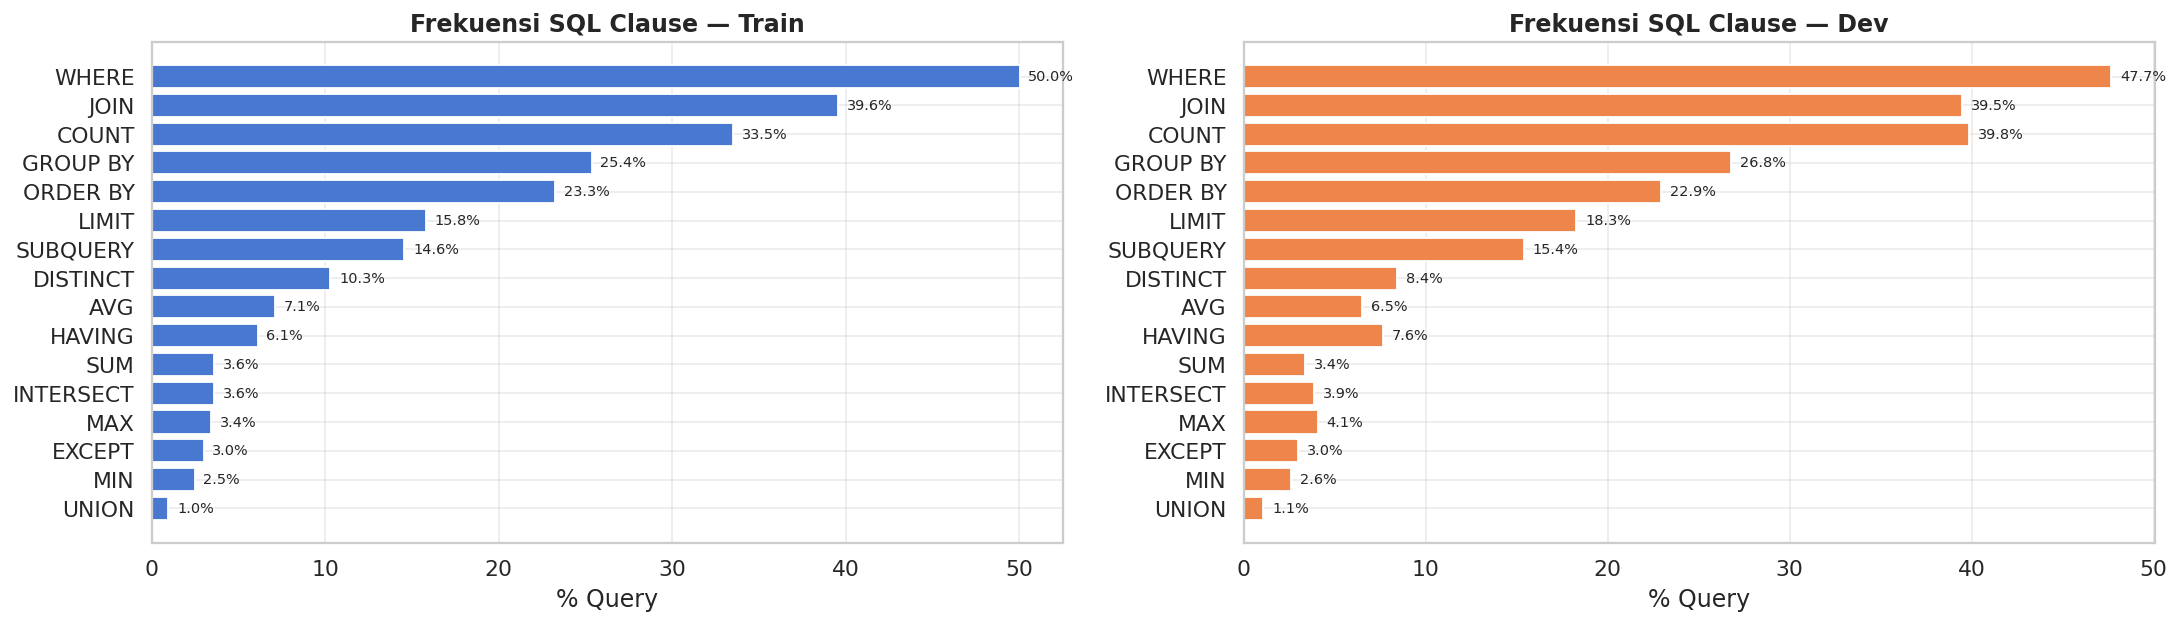

In [14]:
clause_train = (feat_train[clause_cols].mean() * 100).sort_values()
clause_dev   = (feat_dev[clause_cols].mean()   * 100).reindex(clause_train.index)
labels = [c.replace('has_', '').replace('_', ' ').upper() for c in clause_train.index]

fig, axes = plt.subplots(1, 2, figsize=(17, 5))
for ax, vals, title in zip(axes,
                            [clause_train, clause_dev],
                            ['Train', 'Dev']):
    lbl = [c.replace('has_', '').replace('_', ' ').upper() for c in vals.index]
    bars = ax.barh(lbl, vals.values, color=PAL[0 if title=='Train' else 1],
                   edgecolor='white')
    ax.set_title(f'Frekuensi SQL Clause — {title}', fontweight='bold')
    ax.set_xlabel('% Query')
    for i, v in enumerate(vals.values):
        ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('plot_04_sql_clause_freq.png', bbox_inches='tight')
plt.show()

Kolom difficulty tidak ditemukan — membuat difficulty_proxy dari fitur SQL


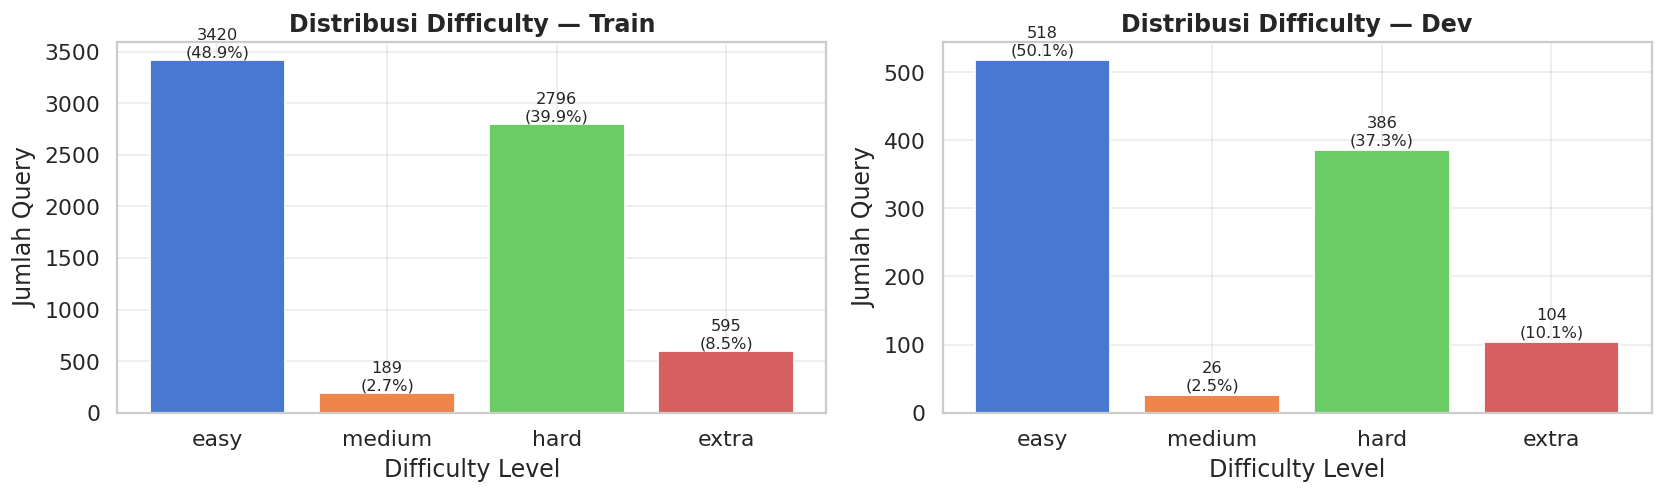

In [15]:
# Deteksi kolom difficulty; jika tidak ada, buat proxy dari SQL features
HARD_COL = None
for cand in ['difficulty', 'hardness', 'level']:
    if cand in df_train.columns:
        HARD_COL = cand
        break

if HARD_COL is None:
    print('Kolom difficulty tidak ditemukan — membuat difficulty_proxy dari fitur SQL')
    def difficulty_proxy(row):
        score = (row.get('has_join', 0) * 1 +
                 row.get('n_joins', 0) * 0.5 +
                 row.get('has_subquery', 0) * 2 +
                 row.get('has_having', 0) * 1 +
                 row.get('has_intersect', 0) * 2 +
                 row.get('has_except', 0) * 2 +
                 row.get('has_union', 0) * 1)
        if score == 0:   return 'easy'
        elif score <= 1: return 'medium'
        elif score <= 3: return 'hard'
        else:            return 'extra'
    df_train['difficulty_proxy'] = df_train.apply(difficulty_proxy, axis=1)
    df_dev['difficulty_proxy']   = df_dev.apply(difficulty_proxy,   axis=1)
    HARD_COL = 'difficulty_proxy'
else:
    print(f'Kolom difficulty ditemukan: {HARD_COL!r}')

order   = ['easy', 'medium', 'hard', 'extra']
present = [o for o in order if o in df_dev[HARD_COL].values]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (df, label) in zip(axes, [(df_train, 'Train'), (df_dev, 'Dev')]):
    counts = df[HARD_COL].value_counts().reindex(order, fill_value=0)
    bars   = ax.bar(counts.index, counts.values, color=PAL[:4], edgecolor='white')
    ax.set_title(f'Distribusi Difficulty — {label}', fontweight='bold')
    ax.set_xlabel('Difficulty Level'); ax.set_ylabel('Jumlah Query')
    for bar in bars:
        h   = bar.get_height()
        pct = h / len(df) * 100
        ax.text(bar.get_x() + bar.get_width() / 2, h + 3,
                f'{int(h)}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('plot_05_hardness.png', bbox_inches='tight')
plt.show()

Statistik Panjang Gold SQL:
          Train                  Dev           
      sql_words sql_tokens sql_words sql_tokens
count   7000.00    7000.00   1034.00    1034.00
mean      15.88      30.94     15.62      30.32
std        9.38      22.39      9.25      21.72
min        4.00       4.00      4.00       4.00
25%        9.00      14.00      9.00      14.00
50%       13.00      22.00     13.00      21.00
75%       21.00      45.00     21.00      43.00
max       87.00     201.00     58.00     130.00


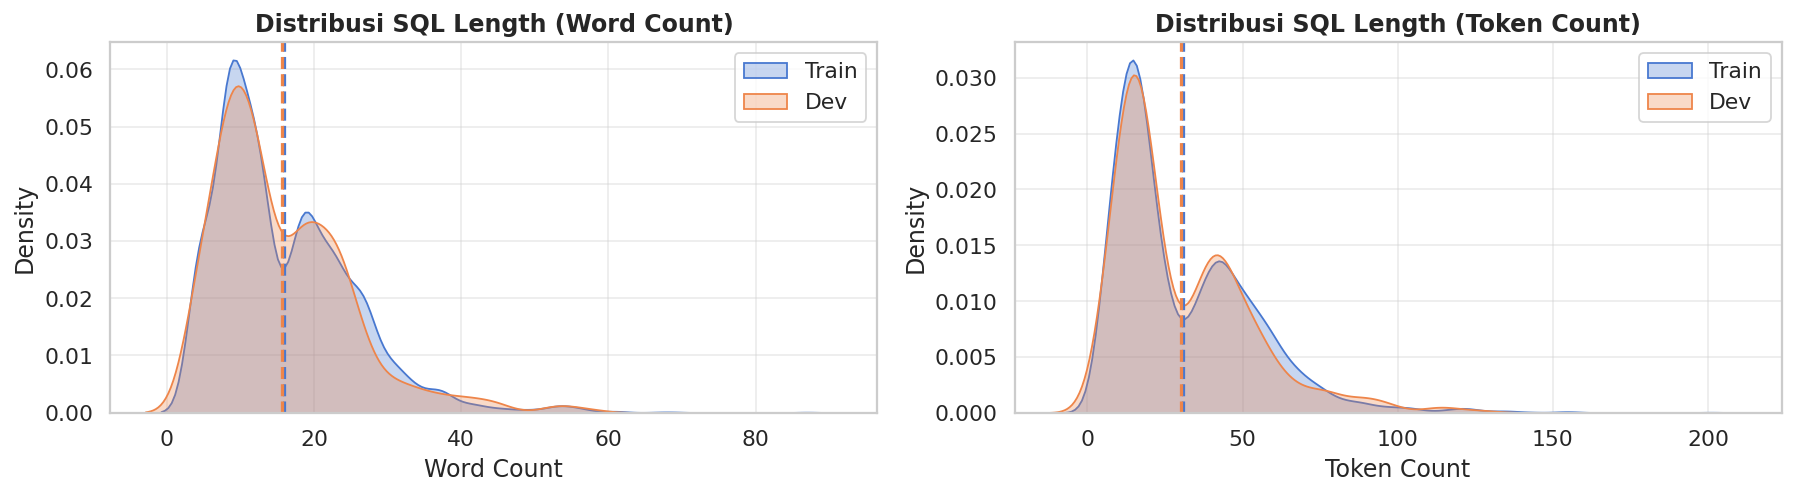

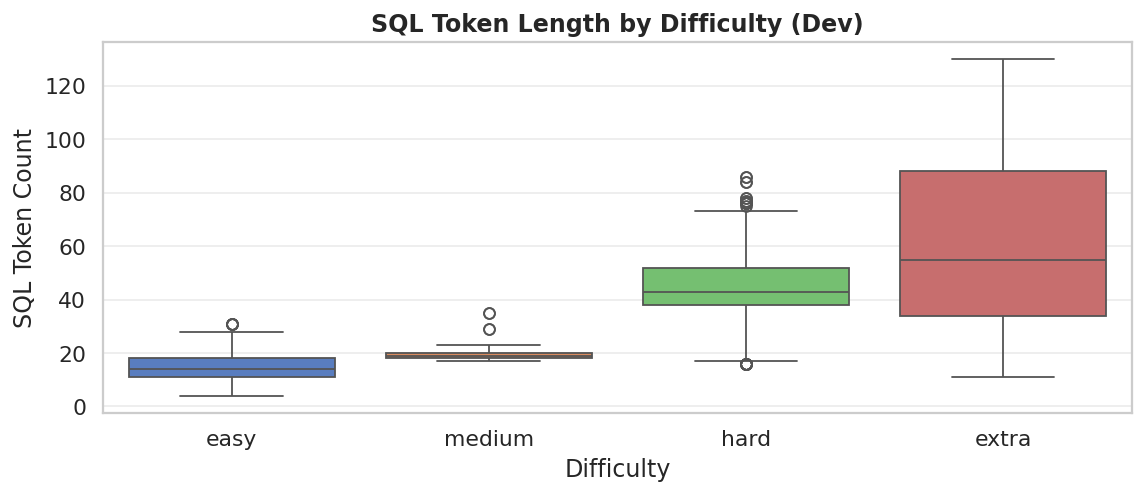

In [16]:
df_train['sql_words']  = df_train[SQL_COL].apply(lambda s: len(str(s).split()))
df_train['sql_tokens'] = df_train[SQL_COL].apply(count_tokens)
df_dev['sql_words']    = df_dev[SQL_COL].apply(lambda s: len(str(s).split()))
df_dev['sql_tokens']   = df_dev[SQL_COL].apply(count_tokens)

print('Statistik Panjang Gold SQL:')
print(pd.concat({'Train': df_train[['sql_words','sql_tokens']].describe(),
                 'Dev'  : df_dev[['sql_words','sql_tokens']].describe()},
                axis=1).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, label in zip(axes, ['sql_words', 'sql_tokens'], ['Word Count', 'Token Count']):
    sns.kdeplot(df_train[col], ax=ax, label='Train', color=PAL[0], fill=True, alpha=0.3)
    sns.kdeplot(df_dev[col],   ax=ax, label='Dev',   color=PAL[1], fill=True, alpha=0.3)
    ax.axvline(df_train[col].mean(), color=PAL[0], lw=1.8, ls='--')
    ax.axvline(df_dev[col].mean(),   color=PAL[1], lw=1.8, ls='--')
    ax.set_title(f'Distribusi SQL Length ({label})', fontweight='bold')
    ax.set_xlabel(label); ax.set_ylabel('Density'); ax.legend()

plt.tight_layout()
plt.savefig('plot_06_sql_length.png', bbox_inches='tight')
plt.show()

# SQL length by difficulty (boxplot)
fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=df_dev, x=HARD_COL, y='sql_tokens', order=present,
            palette='muted', ax=ax)
ax.set_title('SQL Token Length by Difficulty (Dev)', fontweight='bold')
ax.set_xlabel('Difficulty'); ax.set_ylabel('SQL Token Count')
plt.tight_layout()
plt.savefig('plot_06b_sql_tokens_by_diff.png', bbox_inches='tight')
plt.show()

## 6. Analisis Pertanyaan Natural Language

Statistik Panjang Pertanyaan:
         Train               Dev         
       q_words q_tokens  q_words q_tokens
count  7000.00  7000.00  1034.00   1034.0
mean     12.72    14.81    12.43     14.3
std       4.34     5.10     4.28      4.8
min       3.00     4.00     4.00      5.0
25%      10.00    11.00     9.00     11.0
50%      12.00    14.00    12.00     14.0
75%      15.00    18.00    15.00     17.0
max      39.00    50.00    28.00     34.0


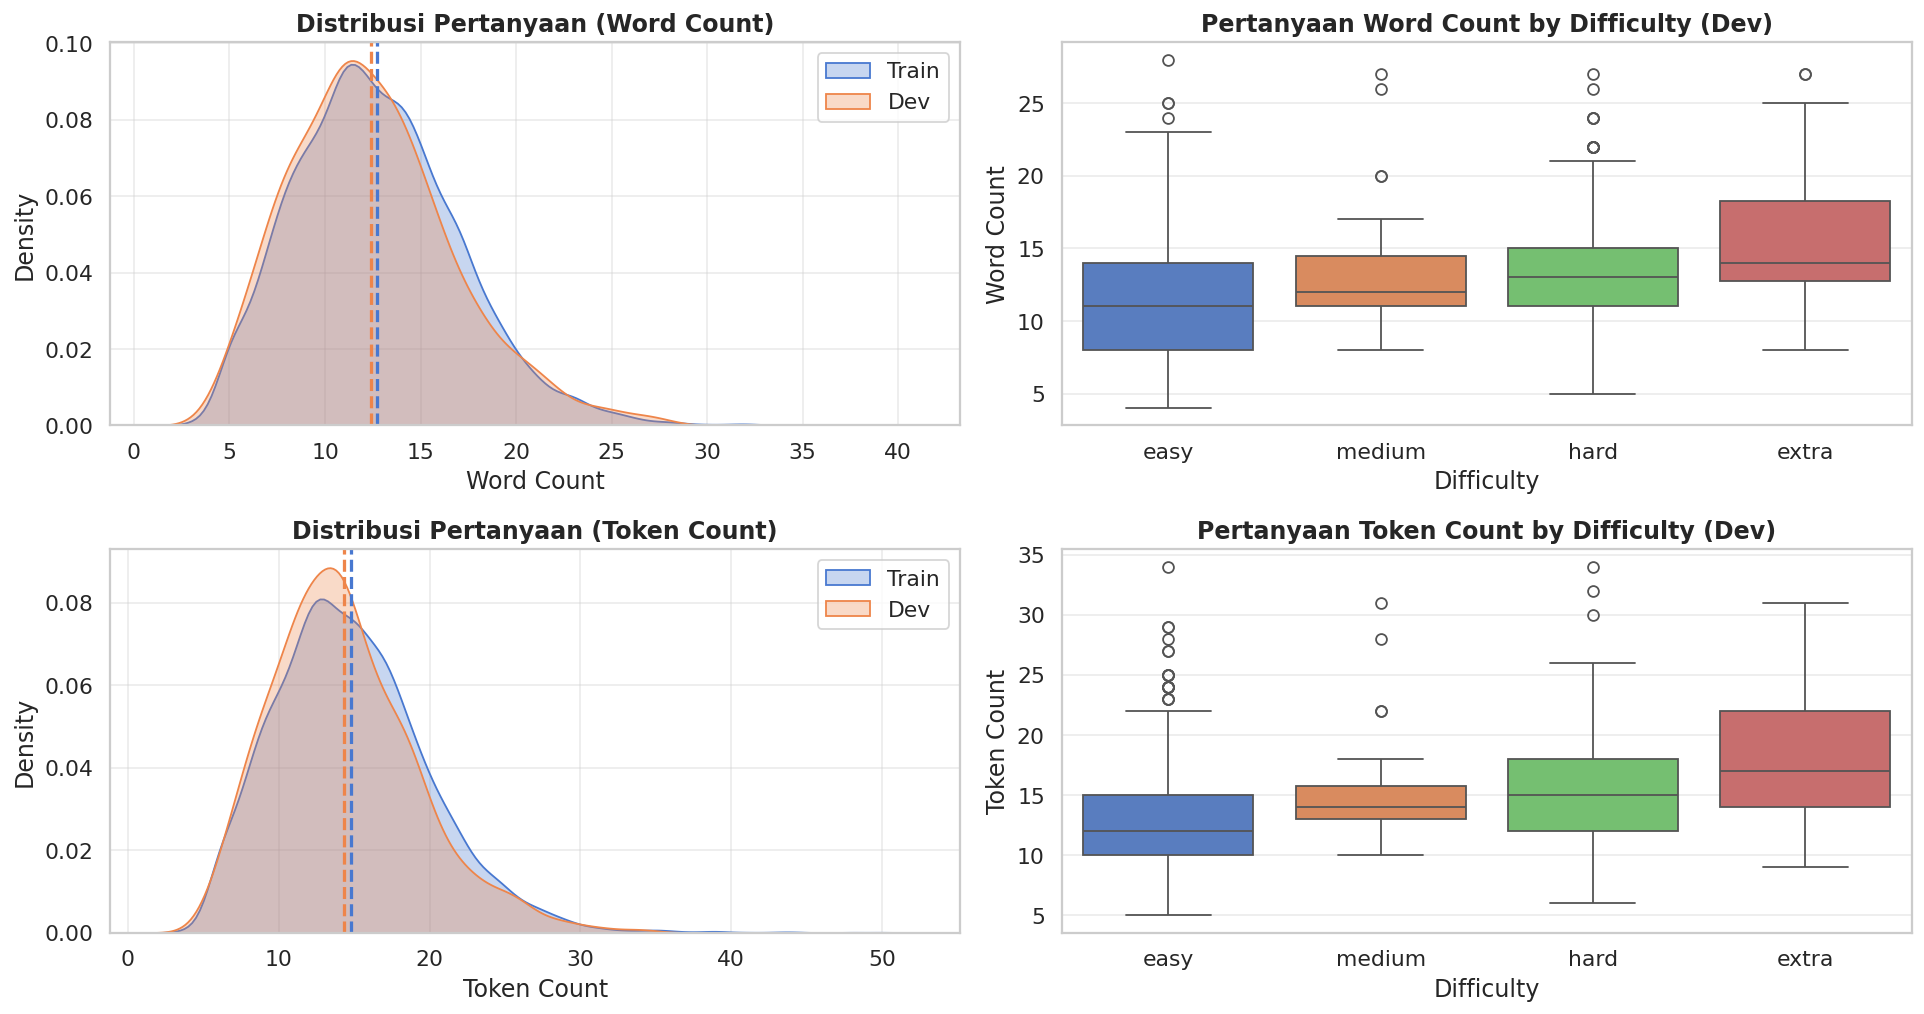

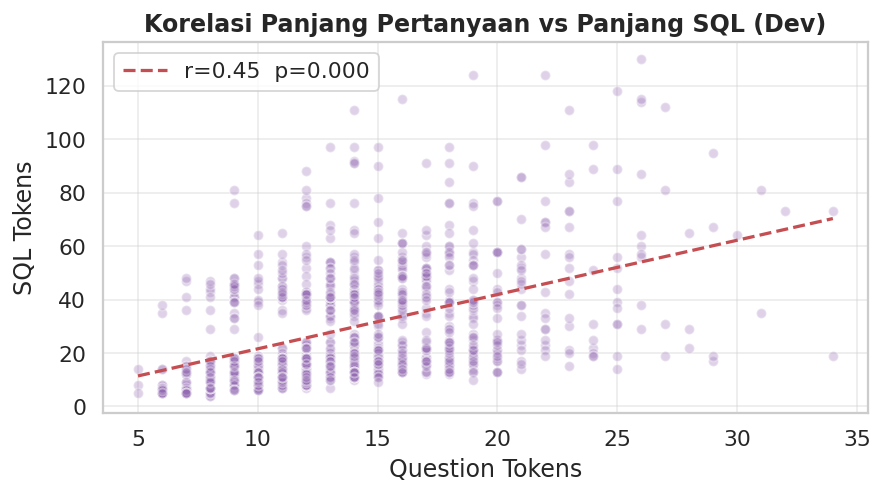

In [17]:
df_train['q_words']  = df_train[Q_COL].apply(lambda s: len(str(s).split()))
df_train['q_tokens'] = df_train[Q_COL].apply(count_tokens)
df_dev['q_words']    = df_dev[Q_COL].apply(lambda s: len(str(s).split()))
df_dev['q_tokens']   = df_dev[Q_COL].apply(count_tokens)

print('Statistik Panjang Pertanyaan:')
print(pd.concat({'Train': df_train[['q_words','q_tokens']].describe(),
                 'Dev'  : df_dev[['q_words','q_tokens']].describe()},
                axis=1).round(2))

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for row_idx, (col, label) in enumerate([('q_words','Word Count'), ('q_tokens','Token Count')]):
    # KDE train vs dev
    ax = axes[row_idx][0]
    sns.kdeplot(df_train[col], ax=ax, label='Train', color=PAL[0], fill=True, alpha=0.3)
    sns.kdeplot(df_dev[col],   ax=ax, label='Dev',   color=PAL[1], fill=True, alpha=0.3)
    ax.axvline(df_train[col].mean(), color=PAL[0], lw=1.8, ls='--')
    ax.axvline(df_dev[col].mean(),   color=PAL[1], lw=1.8, ls='--')
    ax.set_title(f'Distribusi Pertanyaan ({label})', fontweight='bold')
    ax.set_xlabel(label); ax.legend()
    # Boxplot by difficulty
    ax = axes[row_idx][1]
    sns.boxplot(data=df_dev, x=HARD_COL, y=col, order=present, palette='muted', ax=ax)
    ax.set_title(f'Pertanyaan {label} by Difficulty (Dev)', fontweight='bold')
    ax.set_xlabel('Difficulty'); ax.set_ylabel(label)

plt.tight_layout()
plt.savefig('plot_07_question_length.png', bbox_inches='tight')
plt.show()

# Korelasi panjang pertanyaan vs panjang SQL (dev)
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(df_dev['q_tokens'], df_dev['sql_tokens'],
           alpha=0.3, color=PAL[4], edgecolors='white', s=30)
m, b, r, p, _ = stats.linregress(df_dev['q_tokens'], df_dev['sql_tokens'])
xr = np.linspace(df_dev['q_tokens'].min(), df_dev['q_tokens'].max(), 100)
ax.plot(xr, m * xr + b, 'r--', lw=1.8, label=f'r={r:.2f}  p={p:.3f}')
ax.set_xlabel('Question Tokens'); ax.set_ylabel('SQL Tokens')
ax.set_title('Korelasi Panjang Pertanyaan vs Panjang SQL (Dev)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_08_q_vs_sql.png', bbox_inches='tight')
plt.show()

## 7. Analisis Token — Fondasi Token Elasticity of Performance (TEP)

Bagian **paling kritis** untuk skripsi ini. Kita estimasi jumlah token di setiap komponen prompt:

```
PROMPT = [System] + [Schema] + [Few-shot Examples] + [Question]
```

**Perbedaan representasi schema:**
| Komponen | Baseline RAG | GraphRAG |
|---|---|---|
| Schema format | Teks datar (tabel: kolom, ...) | Teks + relasi FK eksplisit |
| Token schema | Lebih sedikit | Lebih banyak (+FK overhead) |
| Informasi relasi | Implisit | Eksplisit (node & edge) |

In [18]:
def schema_tokens_flat(db_id, col_df, tokenizer):
    # Baseline RAG: teks datar per tabel
    # Format: 'Table: <name>\nColumns: col1 (type), col2 (type), ...'
    rows = col_df[col_df['db_id'] == db_id]
    lines = []
    for tbl, grp in rows.groupby('table'):
        col_str = ', '.join(f'{r.column} ({r.type})' for r in grp.itertuples())
        lines.append(f'Table: {tbl}\nColumns: {col_str}')
    return tokenizer('\n\n'.join(lines))


def schema_tokens_graph(db_id, col_df, db_df_meta, tokenizer):
    # GraphRAG: flat schema + FK relationship lines
    # Setiap FK menambahkan 1 baris: 'Relation: Table1.col -> Table2.col'
    flat = schema_tokens_flat(db_id, col_df, tokenizer)
    n_fk_row = db_df_meta[db_df_meta['db_id'] == db_id]['n_fk'].values
    n_fk = int(n_fk_row[0]) if len(n_fk_row) else 0
    # Setiap FK: estimasi 8 token per baris relasi
    fk_tokens = n_fk * 8
    return flat + fk_tokens


print('Menghitung schema tokens per database...')
schema_results = []
for db_id in db_df['db_id'].unique():
    tok_flat  = schema_tokens_flat(db_id, col_df, count_tokens)
    tok_graph = schema_tokens_graph(db_id, col_df, db_df, count_tokens)
    schema_results.append({
        'db_id'      : db_id,
        'schema_flat': tok_flat,
        'schema_graph': tok_graph,
        'fk_overhead': tok_graph - tok_flat,
    })

schema_tok_df = pd.DataFrame(schema_results)
print('Selesai ✓')
print('\nStatistik Schema Tokens per Database:')
print(schema_tok_df[['schema_flat','schema_graph','fk_overhead']].describe().round(1))

Menghitung schema tokens per database...
Selesai ✓

Statistik Schema Tokens per Database:
       schema_flat  schema_graph  fk_overhead
count        166.0         166.0        166.0
mean         173.4         211.7         38.3
std          171.3         201.2         38.5
min           40.0          40.0          0.0
25%           83.2         100.2         16.0
50%          122.5         145.0         24.0
75%          209.8         260.5         48.0
max         1796.0        1948.0        200.0


In [19]:
# ── Estimasi few-shot tokens ─────────────────────────────────────────────
avg_q_tok   = df_train[Q_COL].apply(count_tokens).mean()
avg_sql_tok = df_train[SQL_COL].apply(count_tokens).mean()
avg_fewshot = (avg_q_tok + avg_sql_tok) * FEW_SHOT_K

# ── Merge schema tokens ke df_dev ────────────────────────────────────────
df_dev_tok = df_dev.merge(
    schema_tok_df[['db_id','schema_flat','schema_graph']],
    on='db_id', how='left'
)

# T_in: prompt tokens (system + schema + few-shot + question)
df_dev_tok['T_in_baseline'] = (SYSTEM_TOKENS +
                                df_dev_tok['schema_flat'] +
                                avg_fewshot +
                                df_dev_tok['q_tokens'])

df_dev_tok['T_in_graph']    = (SYSTEM_TOKENS +
                                df_dev_tok['schema_graph'] +
                                avg_fewshot +
                                df_dev_tok['q_tokens'])

# Alias untuk backward compatibility
df_dev_tok['prompt_baseline'] = df_dev_tok['T_in_baseline']
df_dev_tok['prompt_graph']    = df_dev_tok['T_in_graph']

# T_out proxy: gold SQL tokens (estimasi output LLM)
df_dev_tok['T_out_proxy'] = df_dev_tok['sql_tokens']

# ── Token Consumption T = T_in + mu * T_out  (mu=3) ─────────────
MU_OUTPUT = 3  # faktor pengali output token (harga API output 3x lebih mahal)
df_dev_tok['TC_baseline'] = (df_dev_tok['T_in_baseline'] +
                              MU_OUTPUT * df_dev_tok['T_out_proxy'])
df_dev_tok['TC_graph']    = (df_dev_tok['T_in_graph'] +
                              MU_OUTPUT * df_dev_tok['T_out_proxy'])

# ── Delta metrics ─────────────────────────────────────────────────────────
df_dev_tok['token_overhead']  = df_dev_tok['T_in_graph'] - df_dev_tok['T_in_baseline']
df_dev_tok['overhead_pct']    = (df_dev_tok['token_overhead'] /
                                  df_dev_tok['T_in_baseline'] * 100)
df_dev_tok['delta_TC']        = df_dev_tok['TC_graph'] - df_dev_tok['TC_baseline']
df_dev_tok['delta_TC_pct']    = (df_dev_tok['delta_TC'] /
                                  df_dev_tok['TC_baseline'] * 100)

print('=== Estimasi Prompt Tokens (T_in) ===')
print(df_dev_tok[['T_in_baseline','T_in_graph','token_overhead','overhead_pct']].describe().round(1))

print('\n=== Token Consumption T = T_in + 3*T_out (§3.8.2) ===')
print(df_dev_tok[['TC_baseline','TC_graph','delta_TC','delta_TC_pct']].describe().round(1))

print(f'\nKomponen rata-rata (per query dev):')
print(f'  T_in  Baseline : {df_dev_tok["T_in_baseline"].mean():.0f} tok')
print(f'  T_in  GraphRAG : {df_dev_tok["T_in_graph"].mean():.0f} tok')
print(f'  T_out proxy    : {df_dev_tok["T_out_proxy"].mean():.0f} tok')
print(f'  TC    Baseline : {df_dev_tok["TC_baseline"].mean():.0f} tok  (T_in + 3*T_out)')
print(f'  TC    GraphRAG : {df_dev_tok["TC_graph"].mean():.0f} tok  (T_in + 3*T_out)')
print(f'  Delta TC       : {df_dev_tok["delta_TC"].mean():+.0f} tok  ({df_dev_tok["delta_TC_pct"].mean():.1f}%)')

=== Estimasi Prompt Tokens (T_in) ===
       T_in_baseline  T_in_graph  token_overhead  overhead_pct
count         1034.0      1034.0          1034.0        1034.0
mean           385.6       414.8            29.2           7.1
std             93.1       111.4            20.8           3.3
min            275.3       293.3             8.0           2.6
25%            314.3       330.3            16.0           4.7
50%            371.3       389.3            24.0           6.2
75%            385.3       418.3            32.0          10.5
max            635.3       723.3            88.0          14.5

=== Token Consumption T = T_in + 3*T_out (§3.8.2) ===
       TC_baseline  TC_graph  delta_TC  delta_TC_pct
count       1034.0    1034.0    1034.0        1034.0
mean         476.6     505.8      29.2           5.8
std          116.5     132.5      20.8           2.9
min          297.3     308.3       8.0           1.9
25%          396.3     420.3      16.0           3.6
50%          446.3    


* T_in = token prompt (sudah dijelaskan di atas)
* T_out = token output/jawaban SQL yang dihasilkan LLM
* μ = 3 = token output 3× lebih mahal (konvensi harga API)


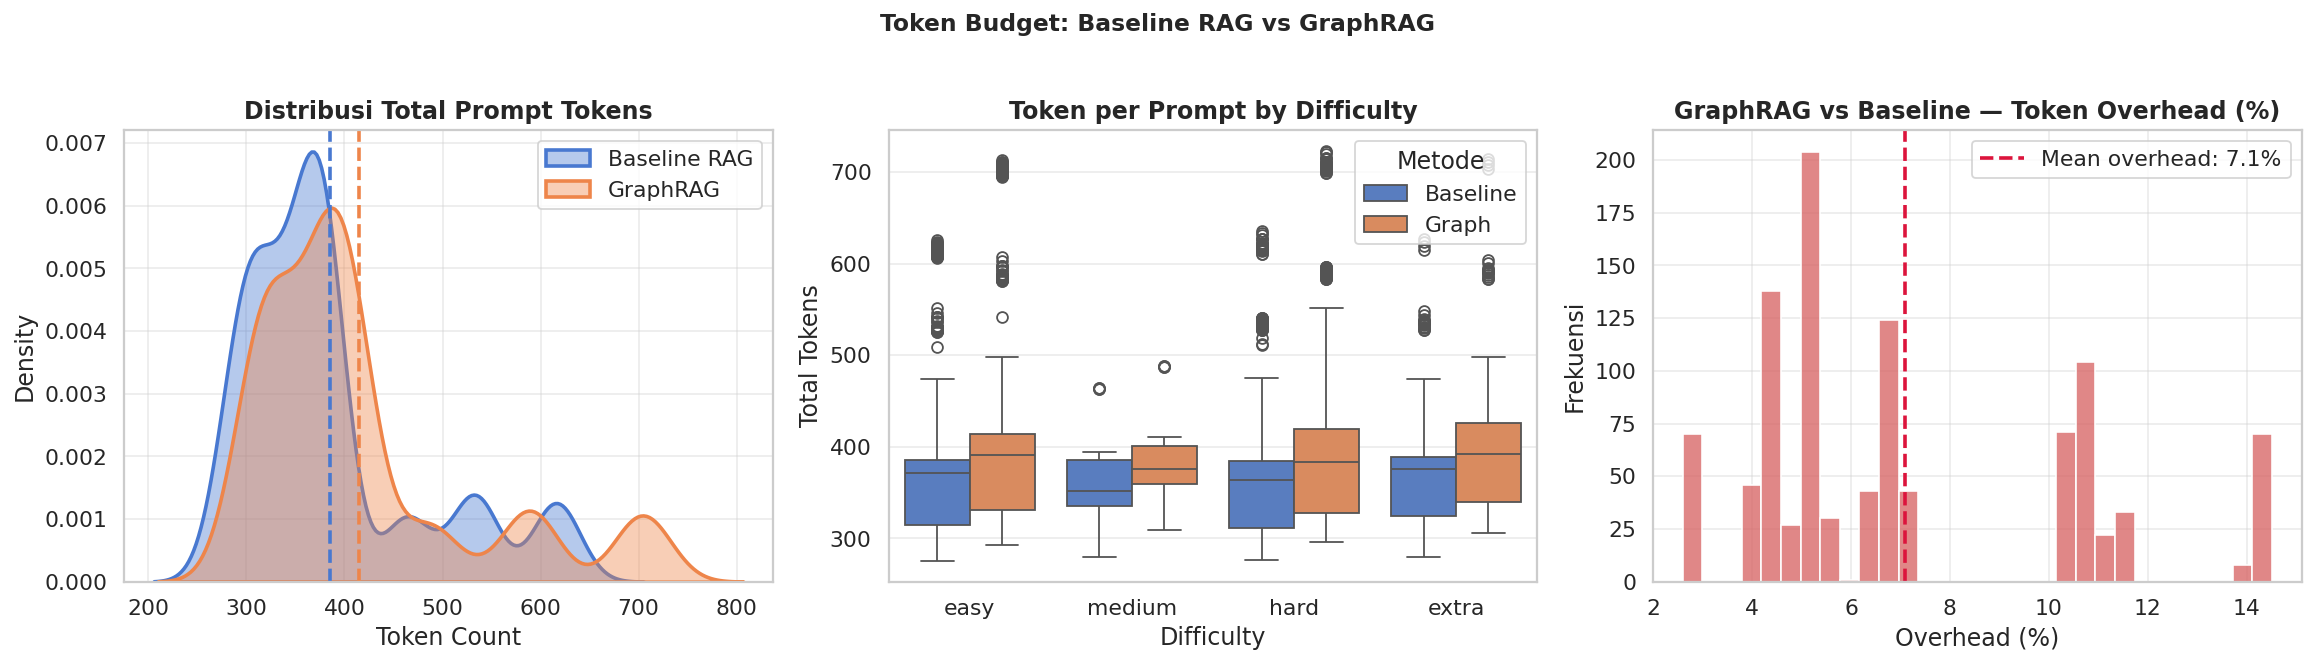

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: KDE baseline vs graph
ax = axes[0]
sns.kdeplot(df_dev_tok['prompt_baseline'], ax=ax, label='Baseline RAG',
            color=PAL[0], fill=True, alpha=0.4, linewidth=2)
sns.kdeplot(df_dev_tok['prompt_graph'],    ax=ax, label='GraphRAG',
            color=PAL[1], fill=True, alpha=0.4, linewidth=2)
ax.axvline(df_dev_tok['prompt_baseline'].mean(), color=PAL[0], lw=2, ls='--')
ax.axvline(df_dev_tok['prompt_graph'].mean(),    color=PAL[1], lw=2, ls='--')
ax.set_title('Distribusi Total Prompt Tokens', fontweight='bold')
ax.set_xlabel('Token Count'); ax.set_ylabel('Density'); ax.legend()

# Panel 2: Boxplot by difficulty
ax = axes[1]
plot_data = pd.melt(df_dev_tok[[HARD_COL, 'prompt_baseline', 'prompt_graph']],
                    id_vars=HARD_COL, var_name='Metode', value_name='Tokens')
plot_data['Metode'] = plot_data['Metode'].map(
    {'prompt_baseline': 'Baseline', 'prompt_graph': 'Graph'})
sns.boxplot(data=plot_data, x=HARD_COL, y='Tokens', hue='Metode',
            order=present, palette=[PAL[0], PAL[1]], ax=ax)
ax.set_title('Token per Prompt by Difficulty', fontweight='bold')
ax.set_xlabel('Difficulty'); ax.set_ylabel('Total Tokens'); ax.legend(title='Metode')

# Panel 3: Overhead distribution
ax = axes[2]
sns.histplot(df_dev_tok['overhead_pct'], bins=30, ax=ax,
             color=PAL[3], edgecolor='white')
mean_oh = df_dev_tok['overhead_pct'].mean()
ax.axvline(mean_oh, color='crimson', lw=2, ls='--',
           label=f'Mean overhead: {mean_oh:.1f}%')
ax.set_title('GraphRAG vs Baseline — Token Overhead (%)', fontweight='bold')
ax.set_xlabel('Overhead (%)'); ax.set_ylabel('Frekuensi'); ax.legend()

plt.suptitle('Token Budget: Baseline RAG vs GraphRAG', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_09_token_budget.png', bbox_inches='tight')
plt.show()

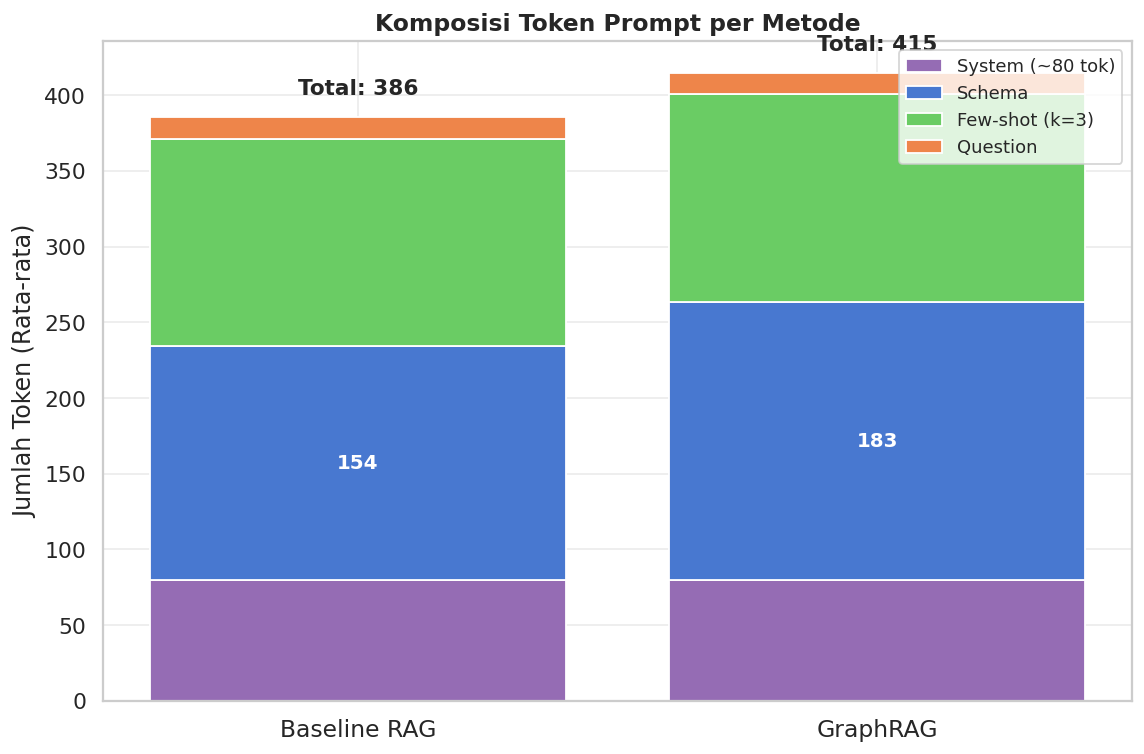

Komponen                    Baseline   GraphRAG    Delta
--------------------------------------------------------
  System prompt                 80.0       80.0     +0.0
  Schema tokens                154.1      183.3    +29.2
  Few-shot (k=3)               137.3      137.3     +0.0
  Question tokens               14.3       14.3     +0.0
--------------------------------------------------------
  TOTAL                        385.6      414.8    +29.2
  Overhead (%)                            7.57%


In [21]:
avg_schema_flat  = df_dev_tok['schema_flat'].mean()
avg_schema_graph = df_dev_tok['schema_graph'].mean()
avg_q_dev        = df_dev_tok['q_tokens'].mean()

methods      = ['Baseline RAG', 'GraphRAG']
sys_vals     = [SYSTEM_TOKENS, SYSTEM_TOKENS]
schema_vals  = [avg_schema_flat,  avg_schema_graph]
fewshot_vals = [avg_fewshot, avg_fewshot]
q_vals       = [avg_q_dev, avg_q_dev]

x = np.arange(len(methods))
fig, ax = plt.subplots(figsize=(9, 6))

b1 = ax.bar(x, sys_vals, color=PAL[4], label=f'System (~{SYSTEM_TOKENS} tok)')
b2 = ax.bar(x, schema_vals, bottom=np.array(sys_vals),
            color=PAL[0], label='Schema')
b3 = ax.bar(x, fewshot_vals,
            bottom=np.array(sys_vals) + np.array(schema_vals),
            color=PAL[2], label=f'Few-shot (k={FEW_SHOT_K})')
b4 = ax.bar(x, q_vals,
            bottom=np.array(sys_vals)+np.array(schema_vals)+np.array(fewshot_vals),
            color=PAL[1], label='Question')

totals = [s+sc+f+q for s,sc,f,q in zip(sys_vals,schema_vals,fewshot_vals,q_vals)]
for i, total in enumerate(totals):
    ax.text(i, total + 15, f'Total: {total:.0f}', ha='center',
            fontweight='bold', fontsize=12)

# Annotasi schema
for i, (bottom, sv) in enumerate(zip(sys_vals, schema_vals)):
    ax.text(i, bottom + sv/2, f'{sv:.0f}', ha='center', va='center',
            color='white', fontweight='bold', fontsize=11)

ax.set_xticks(x); ax.set_xticklabels(methods, fontsize=13)
ax.set_ylabel('Jumlah Token (Rata-rata)')
ax.set_title('Komposisi Token Prompt per Metode', fontweight='bold', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.savefig('plot_10_token_composition.png', bbox_inches='tight')
plt.show()

# Tabel ringkasan
total_base  = SYSTEM_TOKENS + avg_schema_flat  + avg_fewshot + avg_q_dev
total_graph = SYSTEM_TOKENS + avg_schema_graph + avg_fewshot + avg_q_dev
print(f'{"Komponen":<25} {"Baseline":>10} {"GraphRAG":>10} {"Delta":>8}')
print('-' * 56)
rows_tbl = [('System prompt', SYSTEM_TOKENS, SYSTEM_TOKENS),
             ('Schema tokens',  avg_schema_flat,  avg_schema_graph),
             (f'Few-shot (k={FEW_SHOT_K})', avg_fewshot, avg_fewshot),
             ('Question tokens', avg_q_dev, avg_q_dev)]
for name, bv, gv in rows_tbl:
    print(f'  {name:<23} {bv:>10.1f} {gv:>10.1f} {gv-bv:>+8.1f}')
print('-' * 56)
print(f'  {"TOTAL":<23} {total_base:>10.1f} {total_graph:>10.1f} {total_graph-total_base:>+8.1f}')
print(f'  {"Overhead (%)":<23} {"".join([" "]*10)} {(total_graph-total_base)/total_base*100:>9.2f}%')

## 8. Fondasi Token Elasticity of Performance (TEP)

Formula TEP sesuai skripsi §3.8.2 (Zhu et al., 2025):

$$TEP_G = \\frac{\\Delta EX_G / EX_B}{\\Delta T_G / T_B}$$

Di mana:
- $\\Delta EX_G = EX_G - EX_B$ → selisih Execution Accuracy GraphRAG vs Baseline
- $\\Delta T_G = T_G - T_B$ → selisih Token Consumption GraphRAG vs Baseline
- $T = T_{in} + \\mu \\cdot T_{out}$, dengan $\\mu = 3$

**Interpretasi TEP (§3.8.3.1 skripsi):**

| Nilai TEP | Makna |
|---|---|
| **TEP < 0** | Ideal: GraphRAG naik EX & turun token sekaligus |
| **TEP ≈ 0** | Efisiensi token tanpa trade-off EX signifikan |
| **TEP > 0** | Ada trade-off: token turun tapi EX juga turun |

Cell ini mempersiapkan distribusi Token Consumption sebagai denominator TEP.

Token Consumption (T = T_in + 3*T_out) per Difficulty Level:
            TC_base  TC_graph  delta_TC  delta_TC_pct
difficulty                                           
easy          429.1     457.1      28.0           6.1
extra         567.1     597.1      30.1           5.3
hard          519.4     550.5      31.1           5.6
medium        425.0     445.9      20.9           5.0


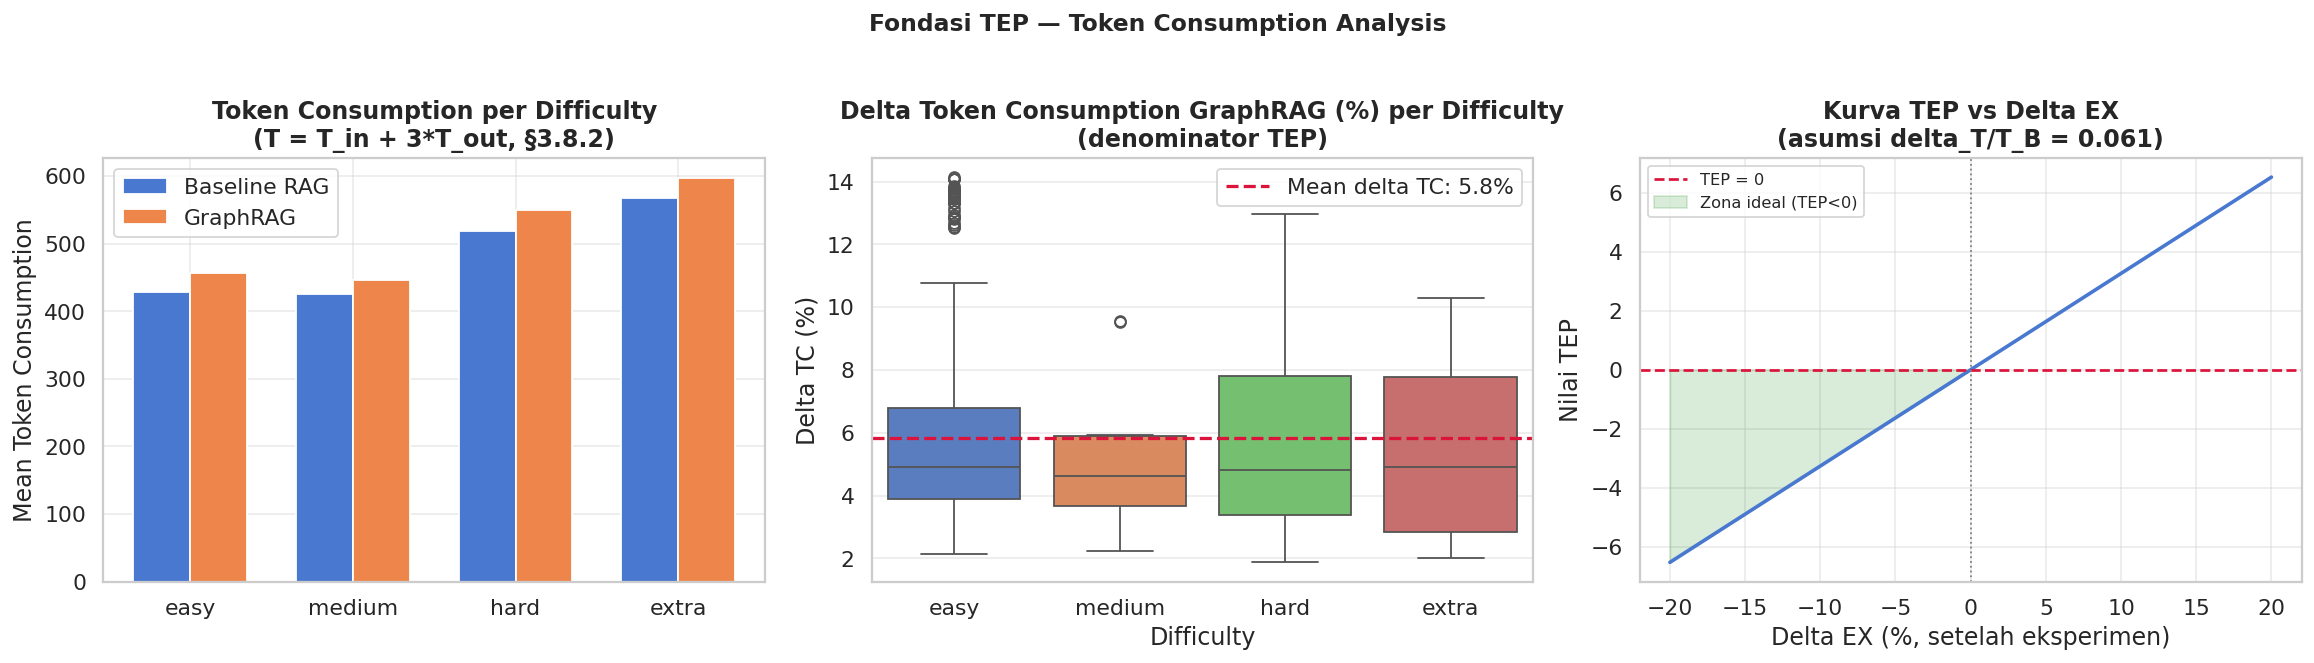


Kalkulasi TEP setelah eksperimen:
  TEP_G = (delta_EX / EX_B) / (delta_TC / TC_B)
  delta_TC / TC_B rata-rata = 0.0613 (6.13%)
  Jika EX_B = 0.50 dan delta_EX = +0.05 maka TEP = 1.632


In [26]:
# ── Token Consumption per difficulty ─────────────────────────────────────
tep_df = df_dev_tok[[HARD_COL,'T_in_baseline','T_in_graph',
                      'TC_baseline','TC_graph',
                      'token_overhead','overhead_pct',
                      'delta_TC','delta_TC_pct']].copy()
tep_df.columns = ['difficulty','T_in_base','T_in_graph',
                   'TC_base','TC_graph',
                   'prompt_overhead','prompt_overhead_pct',
                   'delta_TC','delta_TC_pct']

print('Token Consumption (T = T_in + 3*T_out) per Difficulty Level:')
print(tep_df.groupby('difficulty')[['TC_base','TC_graph','delta_TC','delta_TC_pct']]
      .mean().round(1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Mean Token Consumption per difficulty
ax = axes[0]
tc_by_diff = tep_df.groupby('difficulty')[['TC_base','TC_graph']].mean().reindex(present)
x_d = np.arange(len(present))
w   = 0.35
ax.bar(x_d - w/2, tc_by_diff['TC_base'],  w, label='Baseline RAG', color=PAL[0])
ax.bar(x_d + w/2, tc_by_diff['TC_graph'], w, label='GraphRAG',     color=PAL[1])
ax.set_xticks(x_d); ax.set_xticklabels(present)
ax.set_title('Token Consumption per Difficulty\n(T = T_in + 3*T_out, §3.8.2)', fontweight='bold')
ax.set_ylabel('Mean Token Consumption'); ax.legend()

# Panel 2: Delta TC (%) per difficulty
ax = axes[1]
sns.boxplot(data=tep_df, x='difficulty', y='delta_TC_pct',
            order=present, palette='muted', ax=ax)
mean_dtc = tep_df['delta_TC_pct'].mean()
ax.axhline(mean_dtc, color='crimson', ls='--', lw=1.8,
           label=f'Mean delta TC: {mean_dtc:.1f}%')
ax.set_title('Delta Token Consumption GraphRAG (%) per Difficulty\n(denominator TEP)', fontweight='bold')
ax.set_xlabel('Difficulty'); ax.set_ylabel('Delta TC (%)'); ax.legend()

# Panel 3: Ilustrasi kalkulasi TEP (placeholder — butuh EX aktual)
ax = axes[2]
avg_tc_b = tep_df['TC_base'].mean()
avg_tc_g = tep_df['TC_graph'].mean()
delta_T_ratio = (avg_tc_g - avg_tc_b) / avg_tc_b

# Simulasi: berapa delta_EX yang dibutuhkan untuk TEP < 0
ex_b_sim = 0.50  # asumsi baseline EX 50% (placeholder)
delta_ex_vals = np.linspace(-0.2, 0.2, 100)
tep_vals = (delta_ex_vals / ex_b_sim) / delta_T_ratio
ax.plot(delta_ex_vals * 100, tep_vals, color=PAL[0], lw=2)
ax.axhline(0, color='crimson', ls='--', lw=1.5, label='TEP = 0')
ax.axvline(0, color='gray', ls=':', lw=1)
ax.fill_between(delta_ex_vals*100, tep_vals, 0,
                where=(tep_vals < 0), alpha=0.15, color='green', label='Zona ideal (TEP<0)')
ax.set_xlabel('Delta EX (%, setelah eksperimen)')
ax.set_ylabel('Nilai TEP')
ax.set_title(f'Kurva TEP vs Delta EX\n(asumsi delta_T/T_B = {delta_T_ratio:.3f})', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Fondasi TEP — Token Consumption Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_11_tep_foundation.png', bbox_inches='tight')
plt.show()

print(f'\nKalkulasi TEP setelah eksperimen:')
print(f'  TEP_G = (delta_EX / EX_B) / (delta_TC / TC_B)')
print(f'  delta_TC / TC_B rata-rata = {delta_T_ratio:.4f} ({delta_T_ratio*100:.2f}%)')
print(f'  Jika EX_B = 0.50 dan delta_EX = +0.05 maka TEP = {(0.05/0.50)/delta_T_ratio:.3f}')

## 9. Analisis Schema Linking
Simulasi coverage: apakah jumlah tabel di setiap database bisa dicukupi oleh `top_k_tables`.  
Config aktif: `top_k_tables=3`, `top_k_columns=5`, `sim_threshold=0.35`

Statistik n_tables pada DB yang dipakai di dev:
count    1034.00
mean        4.52
std         2.39
min         2.00
25%         3.00
50%         4.00
75%         4.00
max        11.00
Name: n_tables, dtype: float64

     Top-K |  % DB tercakup | % Query tercakup
------------------------------------------------
  k=1        |           0.0% |             0.0%
  k=2        |          13.9% |             6.8%
  k=3        |          47.0% |            43.6%  <-- konfigurasi aktif
  k=4        |          62.7% |            75.2%
  k=5        |          68.7% |            75.6%
  k=6        |          73.5% |            84.5%
  k=7        |          81.9% |            84.5%
  k=8        |          84.9% |            92.5%
  k=9        |          86.7% |            92.5%
  k=10       |          88.0% |            92.5%


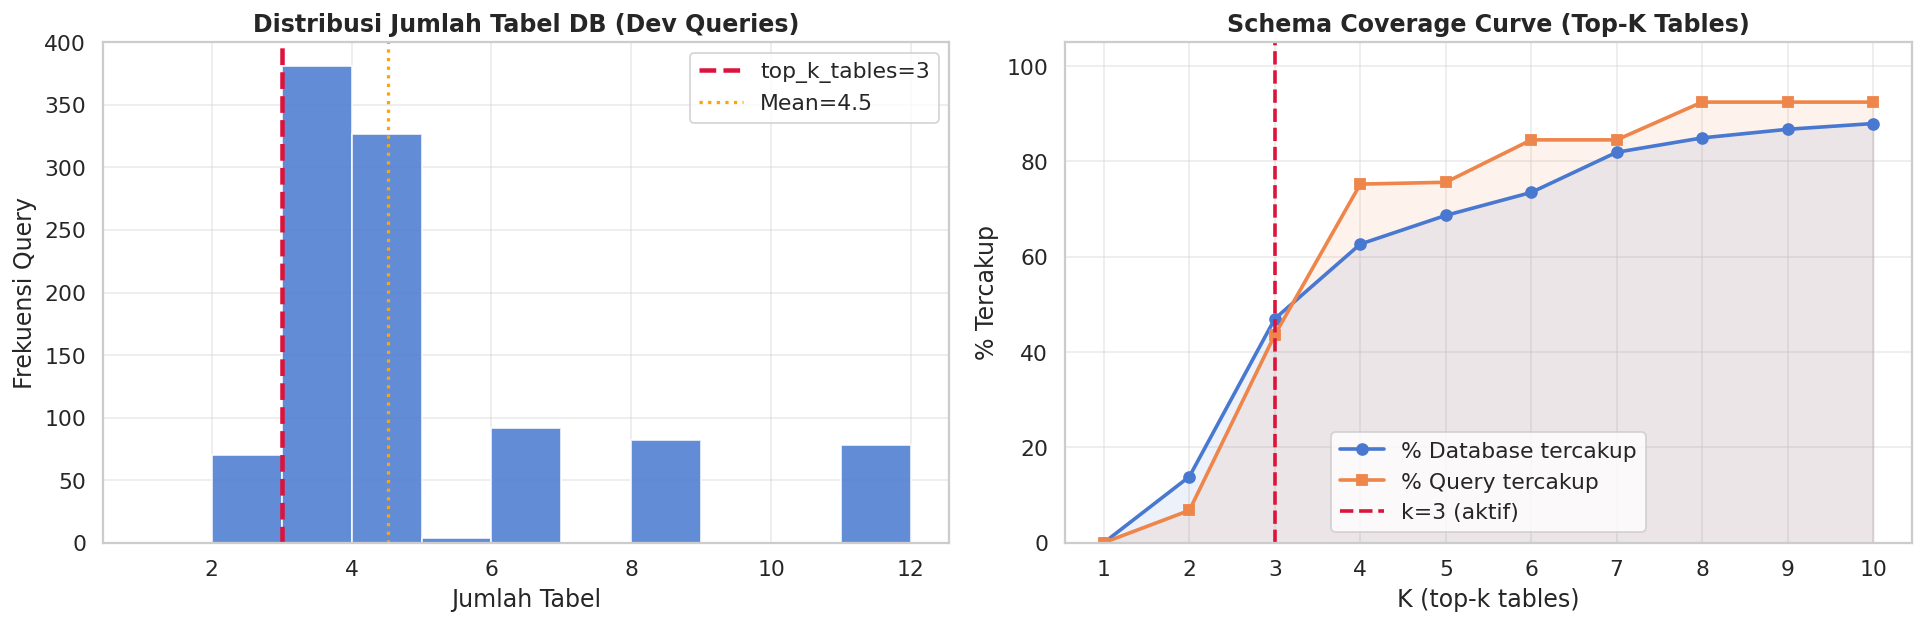

In [23]:
q_with_schema = df_dev.merge(db_df[['db_id','n_tables','n_fk']], on='db_id', how='left')

print('Statistik n_tables pada DB yang dipakai di dev:')
print(q_with_schema['n_tables'].describe().round(2))

print(f'\n{"Top-K":>10} | {"% DB tercakup":>14} | {"% Query tercakup":>16}')
print('-' * 48)
for k in range(1, 11):
    db_cov  = (db_df['n_tables'] <= k).mean() * 100
    q_cov   = (q_with_schema['n_tables'] <= k).mean() * 100
    marker  = '  <-- konfigurasi aktif' if k == TOP_K_TABLES else ''
    print(f'  k={k:<8} | {db_cov:>13.1f}% | {q_cov:>15.1f}%{marker}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribusi n_tables di query dev
ax = axes[0]
ax.hist(q_with_schema['n_tables'].dropna(),
        bins=range(1, int(q_with_schema['n_tables'].max()) + 2),
        color=PAL[0], edgecolor='white', alpha=0.85)
ax.axvline(TOP_K_TABLES, color='crimson', lw=2.5, ls='--',
           label=f'top_k_tables={TOP_K_TABLES}')
ax.axvline(q_with_schema['n_tables'].mean(), color='orange', lw=1.8, ls=':',
           label=f"Mean={q_with_schema['n_tables'].mean():.1f}")
ax.set_title('Distribusi Jumlah Tabel DB (Dev Queries)', fontweight='bold')
ax.set_xlabel('Jumlah Tabel'); ax.set_ylabel('Frekuensi Query'); ax.legend()

# Schema recall curve
ax = axes[1]
ks     = list(range(1, 11))
db_cov = [(db_df['n_tables'] <= k).mean() * 100 for k in ks]
q_cov  = [(q_with_schema['n_tables'] <= k).mean() * 100 for k in ks]
ax.plot(ks, db_cov, 'o-', color=PAL[0], label='% Database tercakup', lw=2)
ax.plot(ks, q_cov,  's-', color=PAL[1], label='% Query tercakup',    lw=2)
ax.fill_between(ks, db_cov, alpha=0.1, color=PAL[0])
ax.fill_between(ks, q_cov,  alpha=0.1, color=PAL[1])
ax.axvline(TOP_K_TABLES, color='crimson', lw=2, ls='--', label=f'k={TOP_K_TABLES} (aktif)')
ax.set_title('Schema Coverage Curve (Top-K Tables)', fontweight='bold')
ax.set_xlabel('K (top-k tables)'); ax.set_ylabel('% Tercakup')
ax.set_xticks(ks); ax.legend(); ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('plot_12_schema_linking.png', bbox_inches='tight')
plt.show()

k=3 → 43.6% query tercakup
* Hanya 43.6% query yang database-nya punya ≤3 tabel → retrieval pasti dapat semua tabel yang dibutuhkan

k=3 → 47.0% DB tercakup
* Hanya 47% database yang total tabelnya ≤3

implikasi:
* k=3  → 43.6% query aman (tabel ≤ 3)
* k=4  → 75.2% query aman  ← lompatan besar di sini
* k=5  → 75.6% query aman  ← hampir tidak naik

## 10. Analisis Few-Shot Examples
Config: `few_shot_k=3`, `few_shot_same_db_first=True`  
Kita analisis ketersediaan same-DB examples di training set untuk setiap dev query.

Few-shot analysis (k=3):
  % dev query cukup same-DB (>= k)    : 0.0%
  % dev query 0 same-DB examples       : 100.0%
  Rata-rata same-DB tersedia           : 0.00
  Rata-rata cross-DB diperlukan        : 3.00


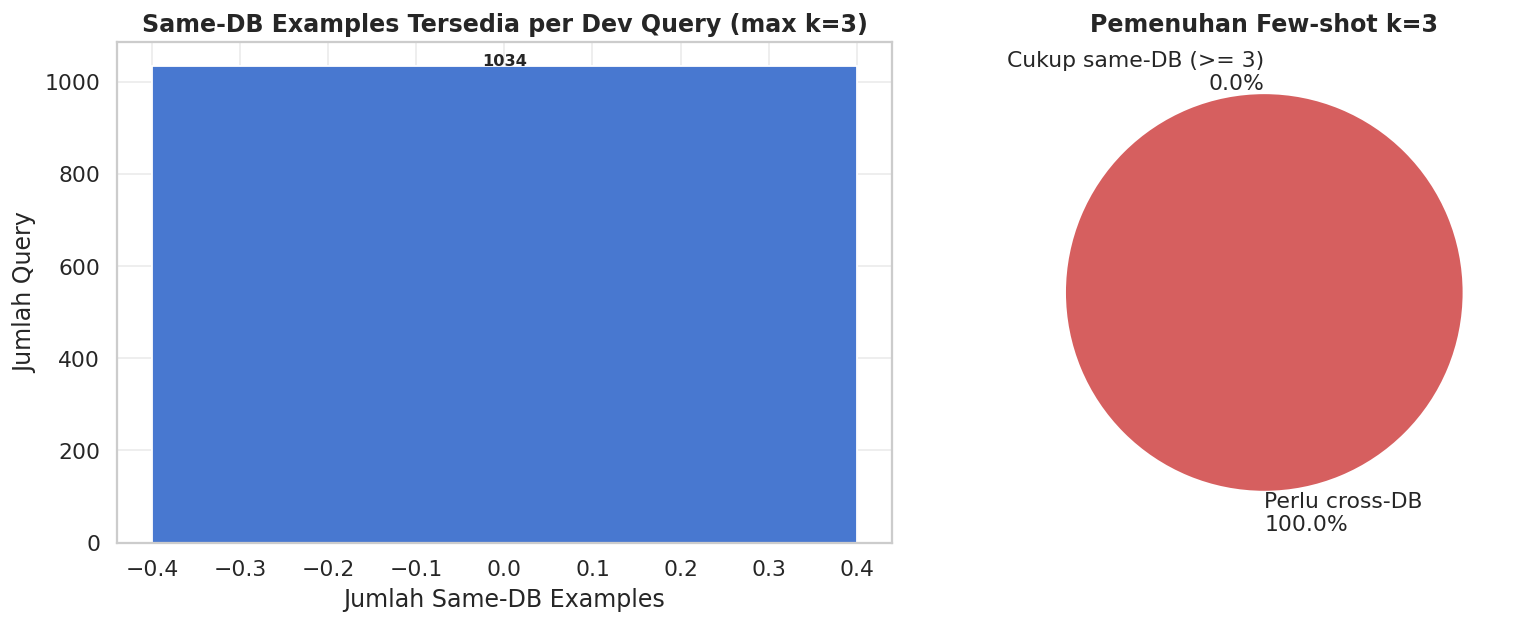

In [24]:
train_db_counts = df_train['db_id'].value_counts()

few_rows = []
for _, row in df_dev.iterrows():
    db        = row['db_id']
    n_same    = train_db_counts.get(db, 0)
    few_rows.append({
        'db_id'          : db,
        'n_same_db_train': n_same,
        'can_fill_k'     : n_same >= FEW_SHOT_K,
        'same_available' : min(n_same, FEW_SHOT_K),
        'cross_needed'   : max(0, FEW_SHOT_K - n_same),
    })
few_df = pd.DataFrame(few_rows)

pct_full = few_df['can_fill_k'].mean() * 100
pct_zero = (few_df['n_same_db_train'] == 0).mean() * 100

print(f'Few-shot analysis (k={FEW_SHOT_K}):')
print(f'  % dev query cukup same-DB (>= k)    : {pct_full:.1f}%')
print(f'  % dev query 0 same-DB examples       : {pct_zero:.1f}%')
print(f'  Rata-rata same-DB tersedia           : {few_df["same_available"].mean():.2f}')
print(f'  Rata-rata cross-DB diperlukan        : {few_df["cross_needed"].mean():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
counts = few_df['same_available'].value_counts().sort_index()
ax.bar(counts.index, counts.values, color=PAL[:len(counts)], edgecolor='white')
ax.set_title(f'Same-DB Examples Tersedia per Dev Query (max k={FEW_SHOT_K})', fontweight='bold')
ax.set_xlabel('Jumlah Same-DB Examples'); ax.set_ylabel('Jumlah Query')
for bar in ax.patches:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 2, str(int(h)),
            ha='center', fontsize=9, fontweight='bold')

ax = axes[1]
ax.pie([pct_full, 100 - pct_full],
       labels=[f'Cukup same-DB (>= {FEW_SHOT_K})\n{pct_full:.1f}%',
               f'Perlu cross-DB\n{100-pct_full:.1f}%'],
       colors=[PAL[0], PAL[3]],
       startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title(f'Pemenuhan Few-shot k={FEW_SHOT_K}', fontweight='bold')

plt.tight_layout()
plt.savefig('plot_13_fewshot.png', bbox_inches='tight')
plt.show()

## 11. Ringkasan EDA

In [25]:
summary_rows = [
    # Dataset
    ('Dataset', 'Total database',           f"{db_df['db_id'].nunique():,}"),
    ('Dataset', 'Train queries',            f"{len(df_train):,}"),
    ('Dataset', 'Dev queries',              f"{len(df_dev):,}"),
    # Schema
    ('Skema',   'Rata-rata tabel/DB',       f"{db_df['n_tables'].mean():.1f} +/- {db_df['n_tables'].std():.1f}"),
    ('Skema',   'Rata-rata kolom/tabel',    f"{cols_per_table['n_cols'].mean():.1f} +/- {cols_per_table['n_cols'].std():.1f}"),
    ('Skema',   'Rata-rata FK/DB',          f"{db_df['n_fk'].mean():.1f} +/- {db_df['n_fk'].std():.1f}"),
    # SQL
    ('SQL',     'Rata-rata SQL tokens',     f"{df_dev['sql_tokens'].mean():.1f} +/- {df_dev['sql_tokens'].std():.1f}"),
    ('SQL',     '% query dengan JOIN',      f"{feat_dev['has_join'].mean()*100:.1f}%"),
    ('SQL',     '% query dengan subquery',  f"{feat_dev['has_subquery'].mean()*100:.1f}%"),
    # Question
    ('Question','Rata-rata q_tokens',       f"{df_dev['q_tokens'].mean():.1f} +/- {df_dev['q_tokens'].std():.1f}"),
    # Token
    ('Token',   'Baseline T_in mean',     f"{df_dev_tok['T_in_baseline'].mean():.0f} tok"),
    ('Token',   'GraphRAG T_in mean',     f"{df_dev_tok['T_in_graph'].mean():.0f} tok"),
    ('Token',   'Baseline TC mean (mu=3)',f"{df_dev_tok['TC_baseline'].mean():.0f} tok"),
    ('Token',   'GraphRAG TC mean (mu=3)',f"{df_dev_tok['TC_graph'].mean():.0f} tok"),
    ('Token',   'Delta TC (denominator TEP)',
     f"{df_dev_tok['delta_TC'].mean():+.0f} tok ({df_dev_tok['delta_TC_pct'].mean():.1f}%)"),
    ('Token',   'Schema flat mean',         f"{schema_tok_df['schema_flat'].mean():.0f} tok/DB"),
    ('Token',   'Schema graph mean',        f"{schema_tok_df['schema_graph'].mean():.0f} tok/DB"),
    # Schema Linking
    ('Schema Linking', f'DB dicakup top_k={TOP_K_TABLES}',
     f"{(db_df['n_tables']<=TOP_K_TABLES).mean()*100:.1f}%"),
    # Few-shot
    ('Few-shot', f'Query >= k same-DB (k={FEW_SHOT_K})', f'{pct_full:.1f}%'),
    ('Few-shot', f'Query 0 same-DB examples',             f'{pct_zero:.1f}%'),
]

summary_final = pd.DataFrame(summary_rows, columns=['Kategori', 'Metrik', 'Nilai'])
print(summary_final.to_string(index=False))

      Kategori                     Metrik          Nilai
       Dataset             Total database            166
       Dataset              Train queries          7,000
       Dataset                Dev queries          1,034
         Skema         Rata-rata tabel/DB    5.3 +/- 3.9
         Skema      Rata-rata kolom/tabel    5.1 +/- 3.9
         Skema            Rata-rata FK/DB    4.8 +/- 4.8
           SQL       Rata-rata SQL tokens  30.3 +/- 21.7
           SQL        % query dengan JOIN          39.5%
           SQL    % query dengan subquery          15.4%
      Question         Rata-rata q_tokens   14.3 +/- 4.8
         Token         Baseline T_in mean        386 tok
         Token         GraphRAG T_in mean        415 tok
         Token    Baseline TC mean (mu=3)        477 tok
         Token    GraphRAG TC mean (mu=3)        506 tok
         Token Delta TC (denominator TEP) +29 tok (5.8%)
         Token           Schema flat mean     173 tok/DB
         Token          Schema 

---
## Implikasi untuk Analisis BAB IV

| Temuan EDA | Implikasi untuk Skripsi |
|---|---|
| Graph overhead **+X% token** | Denominator utama TEP |
| Distribusi difficulty | Stratifikasi analisis ESM per level |
| % query butuh cross-DB few-shot | Variabel kontrol analisis ESM |
| Korelasi tabel vs FK | Faktor moderator dalam trade-off token |
| SQL clause frequency | Subgroup analysis JOIN-heavy vs simple |
| Schema flat vs graph token | Kuantifikasi biaya representasi graph |

---
**Langkah selanjutnya:**
1. Jalankan pipeline Baseline RAG dan GraphRAG pada dev set
2. Kumpulkan: `ESM_score`, `actual_input_tokens`, `actual_output_tokens` per query
3. Hitung TEP = `delta_ESM / (delta_Token / 100)` per subset (all, per-difficulty, per-clause-type)
4. Analisis statistical significance dari perbedaan ESM dan token overhead